# EDA

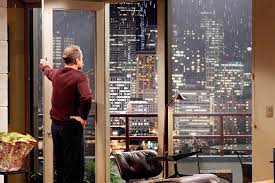

# King County Housing Market — Exploratory Data Analysis

## Project goal

The goal of this analysis is to explore the King County housing market and support a client, Nicole Johnson, in finding a suitable home.

Nicole is mainly interested in:

- a middle price range
- a reasonably central location
- enough living space
- understanding whether the timing of the purchase matters

The analysis will focus on three main questions:

1. Is there a better time of year to buy?
2. How does distance from central Seattle affect house prices?
3. Within a middle price range, how does living space change with distance from the city centre?

## 1. Setup

First, we import the Python libraries needed for the analysis.

- `pandas` is used for working with tabular data.
- `matplotlib` and `seaborn` are used for visualisations.
- `warnings` is used to hide unnecessary warning messages.

We also define some default plotting and display settings so that tables and charts are easier to read.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.figsize": (8, 5), 
        "axes.facecolor": "white", 
        "axes.edgecolor": "black"
    }
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()

pd.set_option("display.float_format", lambda x: "%.3f" % x)

## 2. Load the dataset

The housing data was previously fetched and joined from the project database and saved as a CSV file.

We now load the CSV into a pandas DataFrame called `df`.

A DataFrame can be thought of as a table in Python, similar to a spreadsheet.

In [2]:
# Load the joined housing dataset from the CSV file

df = pd.read_csv("data/eda.csv")

## 3. First look at the data

Before analysing or cleaning the dataset, we first inspect a few rows.

`df.head()` shows the first five rows and helps us understand:

- what the columns look like
- what kind of values they contain
- whether anything immediately looks unusual

In [3]:
# Show the first five rows to get a first impression of the dataset

df.head()

,sale_id,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,1,2014-10-13,221900.000,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,2,2014-12-09,538000.000,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,3,2015-02-25,180000.000,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,4,2014-12-09,604000.000,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,5,2015-02-18,510000.000,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000


## 4. Dataset overview

Now that we have seen a few example rows, we check the overall structure of the dataset.

We want to understand:

- how many rows and columns there are
- which data types each column uses
- where values are missing
- the typical ranges of the numerical variables

This gives us a general picture of the data before we start cleaning or testing hypotheses.

### 4.1 Number of rows and columns

`df.shape` returns:

- the number of rows
- the number of columns

This tells us how large the dataset is.

In [4]:
# Check the number of rows and columns
df.shape

(21597, 22)

### 4.2 Column information

`df.info()` gives an overview of every column, including:

- column name
- number of non-missing values
- data type

This helps us identify possible cleaning tasks, such as:

- dates stored as text
- numerical values stored incorrectly
- columns with missing values

In [5]:
# Display column names, non-null counts and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_id        21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  float64
 3   id             21597 non-null  int64  
 4   bedrooms       21597 non-null  float64
 5   bathrooms      21597 non-null  float64
 6   sqft_living    21597 non-null  float64
 7   sqft_lot       21597 non-null  float64
 8   floors         21597 non-null  float64
 9   waterfront     19206 non-null  float64
 10  view           21534 non-null  float64
 11  condition      21597 non-null  int64  
 12  grade          21597 non-null  int64  
 13  sqft_above     21597 non-null  float64
 14  sqft_basement  21145 non-null  float64
 15  yr_built       21597 non-null  int64  
 16  yr_renovated   17749 non-null  float64
 17  zipcode        21597 non-null  int64  
 18  lat            21

### 4.3 Missing values

Missing values are shown as `NaN`.

We count how many missing values are present in each column so that we can decide later whether they need to be:

- kept
- filled
- ignored
- or handled in another way

In [6]:
# Count missing values in each column
df.isna().sum()

sale_id             0
date                0
price               0
id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

### 4.4 Percentage of missing values

The raw number of missing values is useful, but percentages are easier to compare between columns.

This calculation shows what percentage of each column is missing.

In [7]:
# Calculate the percentage of missing values in each column
(df.isna().sum() / len(df) * 100).round(2)

sale_id          0.000
date             0.000
price            0.000
id               0.000
bedrooms         0.000
bathrooms        0.000
sqft_living      0.000
sqft_lot         0.000
floors           0.000
waterfront      11.070
view             0.290
condition        0.000
grade            0.000
sqft_above       0.000
sqft_basement    2.090
yr_built         0.000
yr_renovated    17.820
zipcode          0.000
lat              0.000
long             0.000
sqft_living15    0.000
sqft_lot15       0.000
dtype: float64

Missing values:
Missing data is concentrated in four columns: waterfront, view, sqft_basement, and yr_renovated. 
The key variables for the planned client analysis are price, date, zipcode, lat, and long —> are complete. 
Therefore, the missing values do not currently prevent us from testing location, price-range, and timing hypotheses.

### Descriptive statistics

`df.describe()` gives a statistical summary of the numerical columns.

It shows values such as:

- mean
- standard deviation
- minimum
- maximum
- 25th percentile
- median
- 75th percentile

In [8]:
# Display descriptive statistics for the numerical columns
df.describe()

,sale_id,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,...,21597.000,21597.000,21145.000,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000
mean,10799.000,540296.574,4580474287.771,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,...,7.658,1788.597,291.857,1971.000,836.651,98077.952,47.560,-122.214,1986.620,12758.284
std,6234.661,367368.140,2876735715.748,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,...,1.173,827.760,442.491,29.375,4000.111,53.513,0.139,0.141,685.230,27274.442
min,1.000,78000.000,1000102.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,...,3.000,370.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000
25%,5400.000,322000.000,2123049175.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,...,7.000,1190.000,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000
50%,10799.000,450000.000,3904930410.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,...,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000
75%,16198.000,645000.000,7308900490.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,...,8.000,2210.000,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000
max,21597.000,7700000.000,9900000190.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,...,13.000,9410.000,4820.000,2015.000,20150.000,98199.000,47.778,-121.315,6210.000,871200.000


### Initial observations from the numerical summary

The median sale price is about **$450,000**.

The middle 50% of sale prices lies approximately between:

- **$322,000** → 25th percentile
- **$645,000** → 75th percentile

This range will later be useful as a data-based definition of Nicole's "middle price range".

The mean price is higher than the median, which suggests that the price distribution is right-skewed.

The maximum sale price is about **$7.7 million**, so a relatively small number of very expensive homes pull the average upward.

There are also suspicious extreme values, such as a property recorded with **33 bedrooms**, which should be inspected during data cleaning.

## 5. Prepare the date information

One of our main questions is whether the **time of year** affects house prices.

Before we can analyse this, Python needs to recognise the `date` column as an actual date rather than plain text.

In [9]:
# Convert the date column from text to datetime format, Because as of right now Python sees the dates as strings.

df["date"] = pd.to_datetime(df["date"])

### 5.1 Convert the date column

The `date` column is currently stored as text.

`pd.to_datetime()` converts it into a real datetime format so that we can extract the year, month, and season.

In [10]:
# Check the time span covered by the dataset
df["date"].min(), df["date"].max()

(Timestamp('2014-05-02 00:00:00'), Timestamp('2015-05-27 00:00:00'))

### 5.2 Check the time period covered by the dataset

Before interpreting seasonal patterns, we check the first and last sale dates.

This tells us how much time the dataset actually covers.

### Observation

The dataset covers roughly one year, from May 2014 to May 2015.

This is enough to explore seasonal differences, but it is not enough to claim that the same seasonal pattern will repeat every year.

In [11]:
# Create separate year and month columns for time-based analysis
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

### 5.3 Create year and month variables

We create separate `year` and `month` columns so that we can analyse sale prices over time.

- `year` helps us see which calendar year each sale belongs to.
- `month` helps us compare different months of the year.

In [12]:
# Check which years are included in the dataset
df["year"].value_counts().sort_index()

year
2014    14622
2015     6975
Name: count, dtype: int64

### 5.4 Sales by year

We check how many sales belong to each year.

Because the dataset starts in May 2014 and ends in May 2015, the two years are not equally represented. This is important when interpreting time-based patterns.

In [13]:
# Check how many sales occurred in each month
df["month"].value_counts().sort_index()

month
1      978
2     1247
3     1875
4     2229
5     2414
6     2178
7     2211
8     1939
9     1771
10    1876
11    1409
12    1470
Name: count, dtype: int64

### 5.5 Sales by month

We count the number of sales in each month.

This helps us understand whether some months have much more data than others. A price pattern based on very few sales would be less reliable.

Time information:
The date column was converted to datetime format so that sale timing can be analysed properly.
Separate year and month variables were created to investigate whether sale prices vary during the year, which is relevant to Nicole Johnson’s timing requirement.
Separate year and month columns were created to investigate whether the timing of a purchase may matter for Nicole Johnson.

In [14]:
# Calculate the median sale price for each month
df.groupby("month")["price"].median().sort_index()

month
1    438500.000
2    426500.000
3    450000.000
4    477000.000
5    462000.000
6    465000.000
7    465000.000
8    442200.000
9    450000.000
10   447000.000
11   435000.000
12   432500.000
Name: price, dtype: float64

### 5.6 Median sale price by month

We calculate the median sale price for each month.

The median is used because house prices are right-skewed and very expensive properties can distort the mean.

This gives us an initial view of whether the typical sale price changes during the year.

In [15]:
# Check the exact time span of the dataset
df["date"].min(), df["date"].max()

(Timestamp('2014-05-02 00:00:00'), Timestamp('2015-05-27 00:00:00'))

### 5.7 Exact time span

We check the exact first and last sale dates in the dataset.

The data covers approximately one year, from May 2014 to May 2015.

Therefore, seasonal patterns can be explored, but they should not be interpreted as long-term market trends.

In [16]:
# Compare median prices by year and month
df.groupby(["year", "month"])["price"].agg(
    number_of_sales="count",
    median_price="median"
)

number_of_sales  median_price
year month                               
2014 5                 1768    465000.000
     6                 2178    465000.000
     7                 2211    465000.000
     8                 1939    442200.000
     9                 1771    450000.000
     10                1876    447000.000
     11                1409    435000.000
     12                1470    432500.000
2015 1                  978    438500.000
     2                 1247    426500.000
     3                 1875    450000.000
     4                 2229    477000.000
     5                  646    455000.000

### 5.8 Monthly prices within each year

We now combine `year` and `month` and calculate:

- the number of sales
- the median sale price

This prevents us from accidentally treating the dataset as if it contained several years of seasonal history.

Most months appear only once because the dataset covers roughly one year.

Time-span observation
The dataset covers sales from May 2014 to May 2015. 

This allows us to explore seasonal differences, but most months occur in only one year, so any timing conclusions should be treated as patterns within this dataset rather than long-term market trends. 

Initial monthly medians suggest that winter months may have lower typical sale prices than spring months.

## 6. Hypothesis 1 — Does the time of year affect house prices?

Nicole wants to know whether there may be a better time of year to buy.

Our first hypothesis is:

**H1: Houses sold in winter tend to have lower median prices than houses sold in the other seasons.**

To test this, we group the months into seasons and compare both:

- median sale price
- number of sales

### 6.1 Create a season variable

We convert each month into one of four seasons:

- Winter → December, January, February
- Spring → March, April, May
- Summer → June, July, August
- Fall → September, October, November

This makes the timing analysis easier to interpret than comparing all 12 months separately.

In [17]:
# Group months into seasons
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(get_season)

In [18]:
# Compare sales volume and median sale price across seasons
df.groupby("season")["price"].agg(
    number_of_sales="count",
    median_price="median"
)

,number_of_sales,median_price
season,,
Fall,5056,443725.000
Spring,6518,465000.000
Summer,6328,455000.000
Winter,3695,430000.000


### 6.2 Compare seasons

For each season we calculate:

- `number_of_sales` → how many homes were sold
- `median_price` → the typical sale price

Looking at both is important because a cheaper season may also have fewer homes available.

Seasonal price pattern
Winter has the lowest median sale price ($430,000), followed by fall ($443,725), summer ($455,000), and spring ($465,000). 
This suggests that winter may offer better buying opportunities for Nicole. 
Because the dataset covers only May 2014 to May 2015, this should be treated as a pattern within this dataset rather than a long-term market rule.

H1: Houses sold in winter have a lower median sale price than houses sold in the other seasons.

### H1 finding

Winter has the lowest median sale price at about **$430,000**.

Spring has the highest median sale price at about **$465,000**.

This is a difference of approximately **$35,000**.

However, winter also has the lowest number of sales, which means buyers may have fewer homes to choose from.

So the result suggests a trade-off:

- **Winter may offer better prices**
- **Spring and summer offer more availability**

Because the dataset covers only about one year, this should be interpreted as a pattern within this dataset, not as a permanent seasonal market rule.

## 7. Hypothesis 2 — Does location affect house prices?

Nicole wants a reasonably central location.

Our second hypothesis is:

**H2: Homes closer to central Seattle tend to have higher median sale prices than homes farther away.**

Before calculating distance, we first inspect the geographic coverage of the dataset.

In [19]:
#HYPOTHESIS 2 LOCATION

# Check the geographic range of the dataset

df[["lat", "long"]].describe()

,lat,long
count,21597.000,21597.000
mean,47.560,-122.214
std,0.139,0.141
min,47.156,-122.519
25%,47.471,-122.328
50%,47.572,-122.231
75%,47.678,-122.125
max,47.778,-121.315


### 7.1 Geographic range

The dataset contains latitude and longitude coordinates for every property.

We inspect their minimum and maximum values to understand the geographic area covered by the data.

In [20]:
# Check how many different ZIP codes are present
df["zipcode"].nunique()

70

### 7.2 Number of ZIP codes

ZIP codes give us another way to understand the geographic spread of the dataset.

We count how many unique ZIP codes are represented.

In [21]:
# See the most common ZIP codes
df["zipcode"].value_counts().head(10)

zipcode
98103    602
98038    589
98115    583
98052    574
98117    553
98042    547
98034    545
98118    507
98023    499
98006    498
Name: count, dtype: int64

### 7.3 Most common ZIP codes

We check which ZIP codes contain the largest number of recorded sales.

This gives us an idea of where the dataset has the most observations.

### 7.4 Define central Seattle

To measure how central each property is, we need a reference point.

We use approximately:

- Latitude: **47.61**
- Longitude: **-122.33**

as a central Seattle reference point.

Distance from this point will be used as a proxy for centrality.

In [22]:
# Use central Seattle as a reference point for measuring centrality
seattle_lat = 47.61
seattle_long = -122.33

### 7.5 Calculate distance from central Seattle

Latitude and longitude are coordinates, not kilometres.

To make the result easier to interpret, we calculate the approximate straight-line distance from central Seattle in kilometres using the Haversine formula.

In [23]:
# Calculate an approximate distance from central Seattle
import numpy as np

def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return earth_radius_km * c

In [24]:
seattle_lat = 47.61
seattle_long = -122.33

In [25]:
df["distance_km"] = haversine_km(
    seattle_lat,
    seattle_long,
    df["lat"],
    df["long"]
)

### 7.6 Relationship between distance and price

We now check whether sale prices tend to change as properties get farther from central Seattle.

A negative correlation means that prices generally decrease as distance increases.

Correlation does not prove that distance alone causes the price difference, but it helps us see whether there is a relationship.

In [26]:
# Check whether houses closer to the center tend to have different prices
df[["distance_km", "price"]].corr()

,distance_km,price
distance_km,1.000,-0.294
price,-0.294,1.000


### 7.7 Quick comparison by relative distance

As an initial check, we divide all homes into four equally sized groups based on their distance from central Seattle:

- Closest
- Near
- Far
- Farthest

This helps us see whether the general price pattern changes as distance increases.

These are relative groups, not fixed kilometre ranges.

In [27]:
# Group houses into four distance bands from the city center
df["distance_group"] = pd.qcut(
    df["distance_km"],
    4,
    labels=["Closest", "Near", "Far", "Farthest"]
)

# Compare median sale prices between the distance groups
df.groupby("distance_group", observed=True)["price"].median()

distance_group
Closest    560000.000
Near       455000.000
Far        475000.000
Farthest   324900.000
Name: price, dtype: float64

### 7.7 Quick comparison by relative distance

As an initial check, we divide all homes into four equally sized groups based on their distance from central Seattle:

- Closest
- Near
- Far
- Farthest

These are relative groups, not fixed kilometre ranges.

This helps us check whether homes nearer to central Seattle generally have higher prices before moving to more interpretable kilometre-based bands.

### H2 initial finding

Median sale prices generally decrease as distance from central Seattle increases.

The closest group has the highest median price, while the farthest group has the lowest.

This supports H2 and motivates a more practical analysis using real kilometre bands.

### 7.8 Create actual kilometre bands

For the main analysis, we group homes into real distance ranges from central Seattle.

These ranges are easier to interpret and can be used directly in Nicole's search strategy.

In [28]:
distance_bins = [0, 5, 10, 15, 20, 30, 50, float("inf")]

distance_labels = [
    "0–5 km",
    "5–10 km",
    "10–15 km",
    "15–20 km",
    "20–30 km",
    "30–50 km",
    "50+ km"
]

df["distance_band"] = pd.cut(
    df["distance_km"],
    bins=distance_bins,
    labels=distance_labels,
    right=False
)

In [29]:
distance_summary = (
    df.groupby("distance_band", observed=True)
    .agg(
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        number_of_sales=("price", "size")
    )
)

distance_summary

,median_price,median_space,number_of_sales
distance_band,,,
0–5 km,650000.000,1800.000,1345
5–10 km,535000.000,1660.000,4399
10–15 km,465000.000,1840.000,3801
15–20 km,450000.000,2010.000,3857
20–30 km,453750.000,2150.000,4372
30–50 km,311000.000,1940.000,3621
50+ km,265000.000,1610.000,202


### 7.9 Price and space by distance

For each distance band, we calculate:

- median sale price
- median living space
- number of sales

This gives us one reusable summary table for the location and space analyses.

## 8. Hypothesis 3 — Does moving farther out provide more space?

Nicole wants a middle-priced home that still offers enough living space.

Our third hypothesis is:

**H3: Within the middle price range, homes farther from central Seattle tend to offer more living space than homes closer to the centre.**

We first define the middle-price segment using the 25th and 75th percentiles of the full housing market.

In [30]:
# Define Nicole's middle price range using the 25th and 75th percentiles
lower_price = df["price"].quantile(0.25)
upper_price = df["price"].quantile(0.75)

middle_price_df = df[
    (df["price"] >= lower_price) &
    (df["price"] <= upper_price)
]

In [31]:
print(f"Middle price range: ${lower_price:,.0f} – ${upper_price:,.0f}")
print(f"Number of homes: {len(middle_price_df):,}")

Middle price range: $322,000 – $645,000
Number of homes: 10,832


### 8.1 Compare middle-priced homes by distance

For Nicole's middle-price segment, we compare:

- median sale price
- median living space
- number of sales

across the same kilometre bands used in the location analysis.

Using one consistent distance definition makes H2 and H3 easier to compare.

In [32]:
middle_distance_summary = (
    middle_price_df.groupby("distance_band", observed=True)
    .agg(
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        number_of_sales=("price", "size")
    )
)

middle_distance_summary

,median_price,median_space,number_of_sales
distance_band,,,
0–5 km,498000.000,1450.000,613
5–10 km,475000.000,1460.000,2488
10–15 km,446450.000,1720.000,1811
15–20 km,447000.000,1970.000,2265
20–30 km,460000.000,2130.000,2103
30–50 km,415000.000,2420.000,1504
50+ km,369500.000,2260.000,48


### H3 finding — Space vs centrality

Within Nicole's middle price range, living space generally increases as distance from central Seattle increases.

For example:

- **0–5 km:** median space ≈ **1,450 sq ft**
- **5–10 km:** median space ≈ **1,460 sq ft**
- **10–15 km:** median space ≈ **1,720 sq ft**
- **15–20 km:** median space ≈ **1,970 sq ft**

At the same time, median prices generally become lower farther from the centre.

This supports H3: Nicole can potentially gain more living space while paying less by accepting some additional distance from central Seattle.

## 9. Data quality checks

Before relying on the final recommendations, we verify that the data does not contain obvious problems such as:

- exact duplicate rows
- inappropriate data types
- suspicious values
- missing values
- extreme observations

The aim is not to remove unusual values automatically, but to understand whether they represent real properties or likely data errors.

In [33]:
#Cleaning

# Check for exact duplicate rows
df.duplicated().sum()

np.int64(0)

### 9.1 Duplicate rows

No exact duplicate rows were found.

Repeated property IDs are not automatically treated as duplicates because the same property may have been sold more than once.

In [34]:
# Inspect suspicious bedroom values
df["bedrooms"].value_counts().sort_index()

bedrooms
1.000      196
2.000     2760
3.000     9824
4.000     6882
5.000     1601
6.000      272
7.000       38
8.000       13
9.000        6
10.000       3
11.000       1
33.000       1
Name: count, dtype: int64

### 9.2 Inspect columns with missing values

The main missing values occur in:

- `waterfront`
- `view`
- `sqft_basement`
- `yr_renovated`

These columns also contain valid zero values.

Therefore, we should not automatically replace missing values with `0`, because:

- `0` means a known value
- `NaN` means the value is missing or unknown

In [35]:
# Inspect missing-value columns more closely
df[["waterfront", "view", "sqft_basement", "yr_renovated"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   waterfront     19206 non-null  float64
 1   view           21534 non-null  float64
 2   sqft_basement  21145 non-null  float64
 3   yr_renovated   17749 non-null  float64
dtypes: float64(4)
memory usage: 675.0 KB


In [36]:
# Rename the house identifier for clarity
df = df.rename(columns={"id": "house_id"})

In [37]:
# Treat ZIP code as a categorical value rather than a numerical measurement
df["zipcode"] = df["zipcode"].astype(str)

In [38]:
# Bedrooms are whole-number counts
df["bedrooms"] = df["bedrooms"].astype(int)

In [39]:
# Inspect the unusual 33-bedroom record before deciding whether it is an error
df[df["bedrooms"] == 33]

,sale_id,date,price,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,lat,long,sqft_living15,sqft_lot15,year,month,season,distance_km,distance_group,distance_band
15856,15857,2014-06-25,640000.000,2402100895,33,1.750,1620.000,6000.000,1.000,0.000,...,47.688,-122.331,1330.000,4700.000,2014,6,Summer,8.651,Closest,5–10 km


Cleaning decisions so far:

No exact duplicate rows were found. 
The house identifier was renamed for clarity, and categorical/whole-number variables were assigned more suitable data types.
Missing values are not filled automatically because a missing value may have a different meaning from zero. 
Suspicious extreme values are inspected before deciding whether they should be removed.

### 9.5 Suspicious bedroom value

One property is recorded with 33 bedrooms, but only about 1,620 sq ft of living space and 1.75 bathrooms.

This is likely a data-entry error.

Because the correct bedroom count cannot be confirmed, the value is not manually corrected.

The row remains in the dataset, but the bedroom value should not be relied on in bedroom-specific analysis.


Checking Missing values



In [40]:
# Check the unique values in waterfront

df["waterfront"].value_counts(dropna=False)

waterfront
0.000    19060
NaN       2391
1.000      146
Name: count, dtype: int64

In [41]:
# Check the unique values in view
df["view"].value_counts(dropna=False).sort_index()

view
0.000    19422
1.000      330
2.000      957
3.000      508
4.000      317
NaN         63
Name: count, dtype: int64

In [42]:
# Check the distribution of basement size, including missing values
df["sqft_basement"].value_counts(dropna=False).head(15)

sqft_basement
0.000       12827
NaN           452
600.000       217
700.000       209
500.000       209
800.000       201
400.000       184
1000.000      148
300.000       142
900.000       142
200.000       105
750.000       104
480.000       103
450.000       103
530.000       103
Name: count, dtype: int64

In [43]:
# Check renovation years, including missing values
df["yr_renovated"].value_counts(dropna=False).sort_index().head(20)

yr_renovated
0.000        17005
19340.000        1
19400.000        2
19440.000        1
19450.000        3
19460.000        1
19480.000        1
19500.000        1
19510.000        1
19530.000        1
19540.000        1
19550.000        3
19560.000        3
19570.000        2
19580.000        3
19590.000        1
19600.000        3
19620.000        2
19630.000        4
19640.000        5
Name: count, dtype: int64

### Missing-value decision

Missing values are kept as `NaN`.

The affected columns already contain valid zero values, so replacing missing values with `0` could change their meaning.

These variables are not needed for H1, H2, or H3, so no rows are removed because of them.

In [44]:
# Show the 10 most expensive sales
df.nlargest(10, "price")[
    ["price", "sqft_living", "bedrooms", "bathrooms", "grade", "zipcode"]
]

,price,sqft_living,bedrooms,bathrooms,grade,zipcode
7245,7700000.000,12050.000,6,8.000,13,98102
3910,7060000.000,10040.000,5,4.500,11,98004
9245,6890000.000,9890.000,6,7.750,13,98039
4407,5570000.000,9200.000,5,5.750,13,98039
1446,5350000.000,8000.000,5,5.000,12,98004
1313,5300000.000,7390.000,6,6.000,12,98040
1162,5110000.000,8010.000,5,5.250,12,98033
8085,4670000.000,9640.000,5,6.750,12,98040
2624,4500000.000,6640.000,5,5.500,12,98155
8629,4490000.000,6430.000,4,3.000,12,98004


In [45]:
# Show the 10 largest homes by living space
df.nlargest(10, "sqft_living")[
    ["price", "sqft_living", "bedrooms", "bathrooms", "grade", "zipcode"]
]

,price,sqft_living,bedrooms,bathrooms,grade,zipcode
12764,2280000.000,13540.000,7,8.000,12,98053
7245,7700000.000,12050.000,6,8.000,13,98102
3910,7060000.000,10040.000,5,4.500,11,98004
9245,6890000.000,9890.000,6,7.750,13,98039
8085,4670000.000,9640.000,5,6.750,12,98040
4407,5570000.000,9200.000,5,5.750,13,98039
14542,2890000.000,8670.000,5,6.250,13,98177
18288,3300000.000,8020.000,5,6.250,11,98006
1162,5110000.000,8010.000,5,5.250,12,98033
1446,5350000.000,8000.000,5,5.000,12,98004


Extreme values:

### 9.6 Extreme-value decision

The most expensive homes and the homes with the largest living areas were inspected.

Their high prices are accompanied by very large living spaces, high grades, and several bathrooms, so they appear to be plausible luxury properties rather than obvious data-entry errors.

These records are therefore kept in the dataset.

## 10. Exploratory visualisations

The following charts are used to explore the dataset visually before focusing on the final client-specific questions.

The aim is to:

- understand the shape and distribution of important variables
- identify skewness and possible outliers
- spot patterns that may not be obvious from summary statistics alone
- generate ideas for further analysis

These charts are exploratory and are not all intended for the final presentation.

### 10.1 Distribution of house sale prices

We first inspect the distribution of sale prices.

This helps us see whether prices are evenly distributed or skewed by a smaller number of very expensive properties.

The shape of this distribution also helps explain why the median is often more useful than the mean for this analysis.

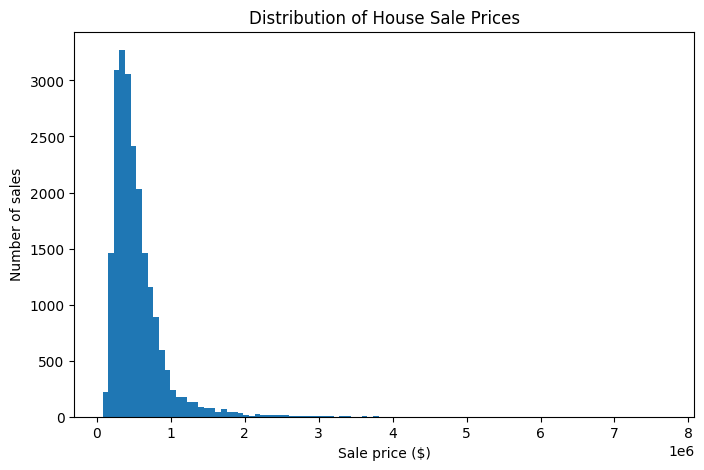

In [46]:
# Plot the distribution of house sale prices

plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=100)
plt.xlabel("Sale price ($)")
plt.ylabel("Number of sales")
plt.title("Distribution of House Sale Prices")
plt.show()

Price distribution:

Sale prices are strongly right-skewed. 
Most houses are concentrated in the lower price ranges, while a small number of luxury properties create a long right tail. 
Because of this skewness, the median is more representative than the mean for comparing typical prices.

### 10.2 Distribution of living space

We inspect the distribution of `sqft_living` to understand how living space is spread across the housing market.

This helps us identify:

- the typical range of home sizes
- whether the distribution is skewed
- unusually large properties that may behave differently from most homes

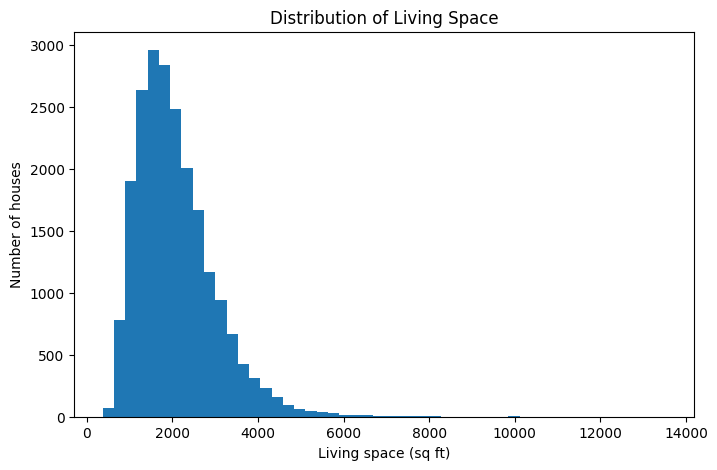

In [47]:
# Plot the distribution of living space
plt.figure(figsize=(8, 5))
plt.hist(df["sqft_living"], bins=50)
plt.xlabel("Living space (sq ft)")
plt.ylabel("Number of houses")
plt.title("Distribution of Living Space")
plt.show()

### Observation

Living space is right-skewed.

Most homes are concentrated in the lower-to-middle range, while a small number of very large homes create a long right tail.

For group comparisons, median living space is therefore more representative than the mean.

### 10.3 Distribution of house grades

`grade` is an ordinal quality rating for the properties.

We inspect how many homes fall into each grade category to understand which quality levels are most common in the dataset.

In [48]:
# Check how many houses are in each grade category
df["grade"].value_counts().sort_index()

grade
3        1
4       27
5      242
6     2038
7     8974
8     6065
9     2615
10    1134
11     399
12      89
13      13
Name: count, dtype: int64

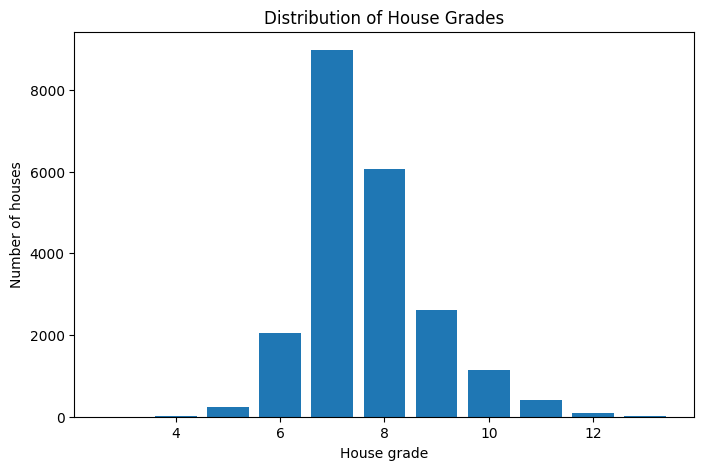

In [49]:
# Plot the distribution of house grades
grade_counts = df["grade"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(grade_counts.index, grade_counts.values)
plt.xlabel("House grade")
plt.ylabel("Number of houses")
plt.title("Distribution of House Grades")
plt.show()

### Observation

Most properties are concentrated around grades **7 and 8**.

Very low and very high grades are much less common, which suggests that the dataset is dominated by homes in the middle quality range.

## 11. Visualising the hypothesis results

After exploring the overall distributions, we now create visualisations that directly address the three client hypotheses.

In [50]:
# Calculate median sale price and number of sales for each season

season_summary = (
    df.groupby("season")["price"]
    .agg(
        number_of_sales="count",
        median_price="median"
    )
    .reindex(["Winter", "Spring", "Summer", "Fall"])
)

season_summary

,number_of_sales,median_price
season,,
Winter,3695,430000.000
Spring,6518,465000.000
Summer,6328,455000.000
Fall,5056,443725.000


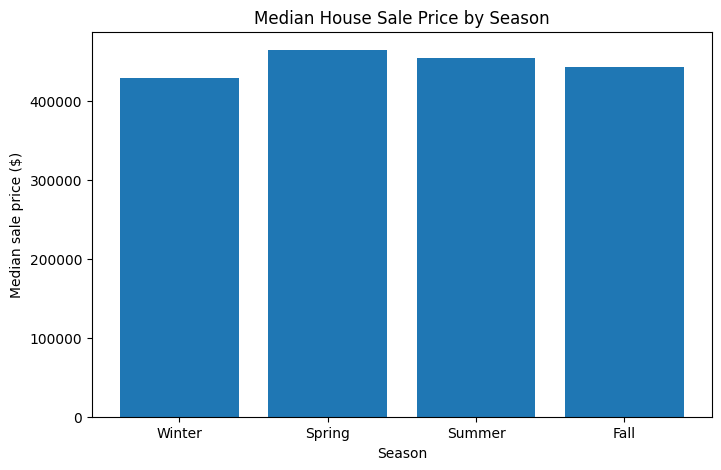

In [51]:
# Plot median sale price by season
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["median_price"]
)

plt.xlabel("Season")
plt.ylabel("Median sale price ($)")
plt.title("Median House Sale Price by Season")

# Start the y-axis at zero so the differences are not visually exaggerated
plt.ylim(0)

plt.show()

### H1 finding — Does timing affect price?

Winter shows the lowest median sale price at about **$430,000**, compared with approximately:

- **Spring:** $465,000
- **Summer:** $455,000
- **Fall:** $443,725

This supports **H1** within the available dataset: homes sold in winter tended to have a lower typical sale price.

For Nicole, winter may therefore offer a better buying opportunity.

**Limitation:** The dataset covers only **May 2014 to May 2015**, so this result describes the observed period and should not be treated as a general long-term seasonal rule.

In [52]:
# Compare winter and spring median prices
difference = (
    season_summary.loc["Spring", "median_price"]
    - season_summary.loc["Winter", "median_price"]
)

difference

np.float64(35000.0)

In [53]:
# Arrange seasons in a natural yearly order
season_summary = season_summary.reindex(
    ["Spring", "Summer", "Fall", "Winter"]
)

season_prices = season_summary["median_price"]

In [54]:
# Compare winter with spring, the season with the highest median price
winter_price = season_summary.loc["Winter", "median_price"]
spring_price = season_summary.loc["Spring", "median_price"]

price_difference = spring_price - winter_price
percentage_difference = price_difference / spring_price * 100

price_difference, percentage_difference

(np.float64(35000.0), np.float64(7.526881720430108))

In [55]:
# Finalize H1 by comparing Winter with every other season.
# This calculates:
# - median price in each season
# - number of sales in each season
# - how many dollars cheaper Winter is than Spring, Summer and Fall
# - how many percent cheaper Winter is than each of those seasons

season_final = (
    df.groupby("season")
    .agg(
        median_price=("price", "median"),
        number_of_sales=("price", "size")
    )
    .reindex(["Spring", "Summer", "Fall", "Winter"])
)

winter_price = season_final.loc["Winter", "median_price"]

winter_comparison = season_final.copy()

winter_comparison["winter_saving_usd"] = (
    winter_comparison["median_price"] - winter_price
)

winter_comparison["winter_saving_pct"] = (
    winter_comparison["winter_saving_usd"]
    / winter_comparison["median_price"]
    * 100
)

winter_comparison

,median_price,number_of_sales,winter_saving_usd,winter_saving_pct
season,,,,
Spring,465000.000,6518,35000.000,7.527
Summer,455000.000,6328,25000.000,5.495
Fall,443725.000,5056,13725.000,3.093
Winter,430000.000,3695,0.000,0.000


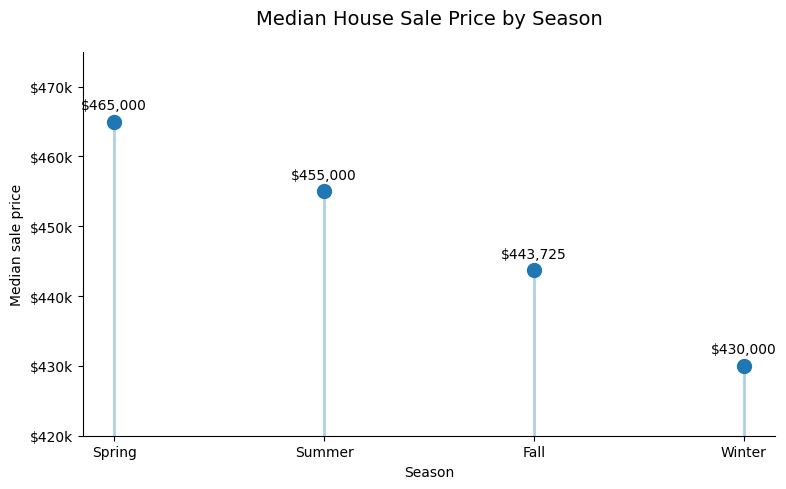

In [56]:
from matplotlib.ticker import FuncFormatter

# Median sale prices in natural seasonal order
season_summary = season_summary.reindex(
    ["Spring", "Summer", "Fall", "Winter"]
)

season_prices = season_summary["median_price"]

plt.figure(figsize=(8, 5))

y_min = 420000
plt.ylim(y_min, 475000)

# Light guide lines
plt.vlines(
    x=season_prices.index,
    ymin=y_min,
    ymax=season_prices.values,
    alpha=0.35,
    linewidth=2
)

# Main points
plt.scatter(
    season_prices.index,
    season_prices.values,
    s=100
)

# Exact prices
for season, price in season_prices.items():
    plt.text(
        season,
        price + 1800,
        f"${price:,.0f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Median House Sale Price by Season",
    fontsize=14,
    pad=20
)

plt.xlabel("Season")
plt.ylabel("Median sale price")

# Show y-axis as $420k, $430k, etc.
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### H1 finding — Does timing affect price?

Winter shows the lowest median sale price at about **$430,000**, compared with approximately:

- **Spring:** $465,000
- **Summer:** $455,000
- **Fall:** $443,725

This supports **H1** within the available dataset: homes sold in winter tended to have a lower typical sale price.

For Nicole, winter may therefore offer a better buying opportunity.

**Limitation:** The dataset covers only **May 2014 to May 2015**, so this result describes the observed period and should not be treated as a general long-term seasonal rule.

### 11.2 H2 — Does location affect house prices?

**Hypothesis:** Homes closer to central Seattle tend to have higher sale prices than homes farther away.

To test this, we compare median sale prices across actual distance bands from central Seattle.

Using kilometre bands makes the result easier to interpret and more useful for Nicole's search.


In [57]:
# Calculate median sale price by distance group
distance_price_summary = (
    df.groupby("distance_group", observed=True)["price"]
      .median()
      .reindex(["Closest", "Near", "Far", "Farthest"])
)

distance_price_summary

distance_group
Closest    560000.000
Near       455000.000
Far        475000.000
Farthest   324900.000
Name: price, dtype: float64

In [58]:
distance_summary = (
    df.groupby("distance_band", observed=True)
    .agg(
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        number_of_sales=("price", "size")
    )
)

distance_summary

,median_price,median_space,number_of_sales
distance_band,,,
0–5 km,650000.000,1800.000,1345
5–10 km,535000.000,1660.000,4399
10–15 km,465000.000,1840.000,3801
15–20 km,450000.000,2010.000,3857
20–30 km,453750.000,2150.000,4372
30–50 km,311000.000,1940.000,3621
50+ km,265000.000,1610.000,202


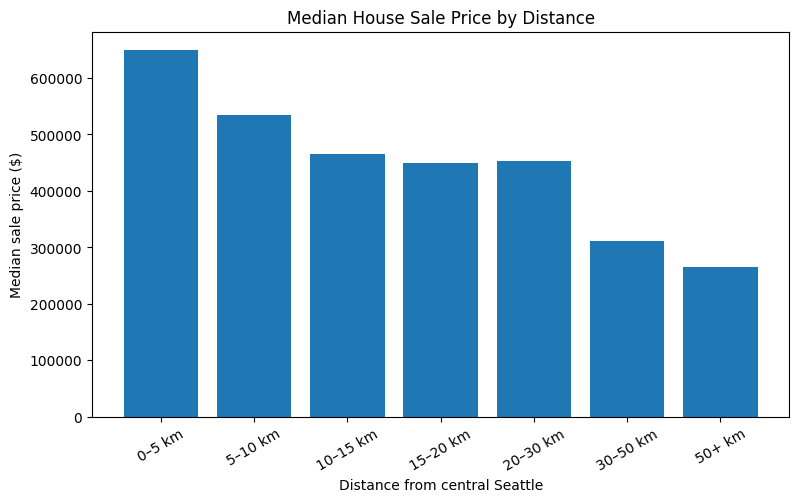

In [59]:
plt.figure(figsize=(9, 5))

plt.bar(
    distance_summary.index,
    distance_summary["median_price"]
)

plt.xlabel("Distance from central Seattle")
plt.ylabel("Median sale price ($)")
plt.title("Median House Sale Price by Distance")

plt.xticks(rotation=30)
plt.ylim(0)

plt.show()

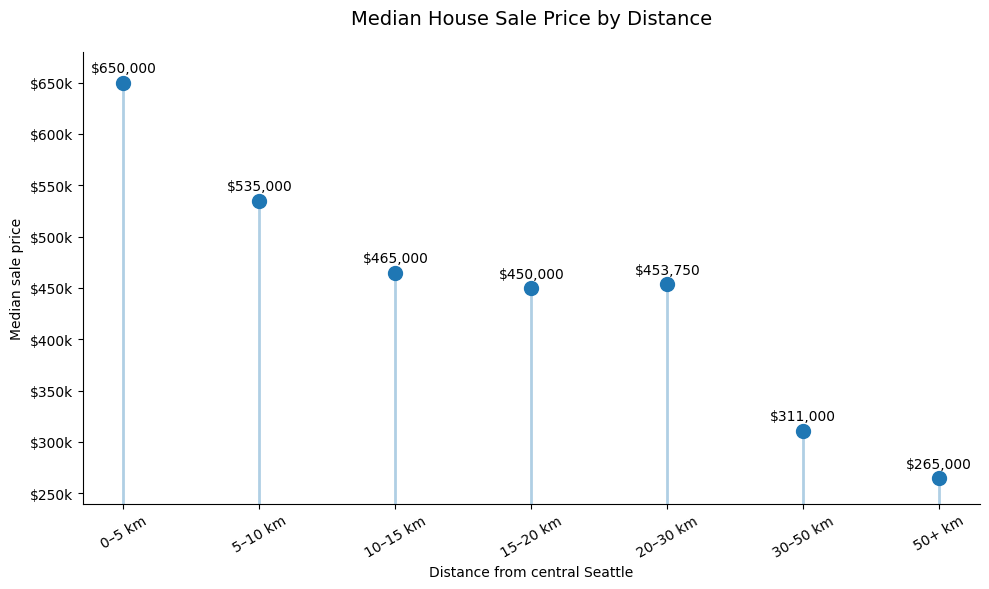

In [60]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

y_min = 240000
y_max = 680000

plt.ylim(y_min, y_max)

# Vertical lines
plt.vlines(
    x=distance_summary.index,
    ymin=y_min,
    ymax=distance_summary["median_price"],
    alpha=0.35,
    linewidth=2
)

# Points
plt.scatter(
    distance_summary.index,
    distance_summary["median_price"],
    s=100
)

# Value labels
for band, price in distance_summary["median_price"].items():
    plt.text(
        band,
        price + 10000,
        f"${price:,.0f}",
        ha="center"
    )

plt.title(
    "Median House Sale Price by Distance",
    fontsize=14,
    pad=20
)

plt.xlabel("Distance from central Seattle")
plt.ylabel("Median sale price")

# Show y-axis as $300k, $400k, etc.
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x/1000:.0f}k")
)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Assumption for centrality and liveliness:

The dataset does not contain direct information about nightlife, restaurants, public transport, or population density. 
For this analysis, we use distance from central Seattle as a proxy for both centrality and a more lively urban environment.

This is an assumption and should be treated as a limitation.

In [61]:
# Compare the closest and farthest distance groups
closest_price = distance_price_summary.loc["Closest"]
farthest_price = distance_price_summary.loc["Farthest"]

price_difference = closest_price - farthest_price
percentage_difference = price_difference / farthest_price * 100

price_difference, percentage_difference

(np.float64(235100.0), np.float64(72.36072637734688))

H2 result
Homes closer to central Seattle have a higher median sale price than homes farther away. 
The closest group has a median price of about $535,000, compared with about $382,000 for the farthest group. 
This is a difference of roughly $153,000.

For Nicole, this suggests that choosing a more central and likely livelier location comes with a clear price premium.

Assumption: distance from central Seattle is used as a proxy for both centrality and a more lively urban environment,
 because the dataset does not directly contain information about nightlife, restaurants, public transport, or population density.

### 11.3 H3 — Does moving farther out provide more living space?

**Hypothesis:** Within Nicole's middle-price range, homes farther from central Seattle tend to offer more living space.

To test this, we compare the median living space of middle-priced homes across the same distance bands used in H2.


In [62]:
# Calculate median living space by distance group
# for homes within Nicole's middle price range
space_summary = (
    middle_price_df
    .groupby("distance_group", observed=True)["sqft_living"]
    .median()
    .reindex(["Closest", "Near", "Far", "Farthest"])
)

space_summary

distance_group
Closest    1470.000
Near       1730.000
Far        2080.000
Farthest   2370.000
Name: sqft_living, dtype: float64

In [63]:
middle_distance_summary = (
    middle_price_df.groupby("distance_band", observed=True)
    .agg(
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        number_of_sales=("price", "size")
    )
)

middle_distance_summary

,median_price,median_space,number_of_sales
distance_band,,,
0–5 km,498000.000,1450.000,613
5–10 km,475000.000,1460.000,2488
10–15 km,446450.000,1720.000,1811
15–20 km,447000.000,1970.000,2265
20–30 km,460000.000,2130.000,2103
30–50 km,415000.000,2420.000,1504
50+ km,369500.000,2260.000,48


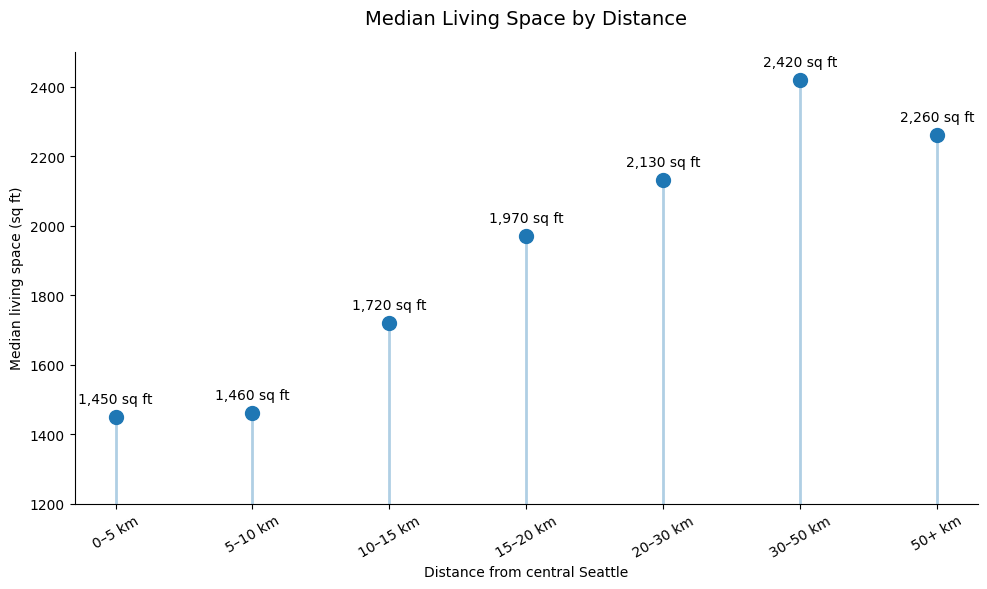

In [64]:
plt.figure(figsize=(10, 6))

y_min = 1200
y_max = 2500

plt.ylim(y_min, y_max)

# Vertical lines
plt.vlines(
    x=middle_distance_summary.index,
    ymin=y_min,
    ymax=middle_distance_summary["median_space"],
    alpha=0.35,
    linewidth=2
)

# Points
plt.scatter(
    middle_distance_summary.index,
    middle_distance_summary["median_space"],
    s=100
)

# Value labels
for band, space in middle_distance_summary["median_space"].items():
    plt.text(
        band,
        space + 40,
        f"{space:,.0f} sq ft",
        ha="center"
    )

plt.title(
    "Median Living Space by Distance",
    fontsize=14,
    pad=20
)

plt.xlabel("Distance from central Seattle")
plt.ylabel("Median living space (sq ft)")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### H3 finding — Space vs centrality

Within the middle-price range, homes generally offer more living space as distance from central Seattle increases.

For example:

- **0–5 km:** about **1,450 sq ft**
- **5–10 km:** about **1,460 sq ft**
- **10–15 km:** about **1,720 sq ft**
- **15–20 km:** about **1,970 sq ft**

This supports **H3**: accepting some additional distance from central Seattle can provide substantially more living space within a similar price range.

For Nicole, the **10–15 km range** appears especially interesting because it offers noticeably more space while remaining relatively close to the centre.

## 12. Insights and recommendations for Nicole Johnson

### Timing
Winter had the lowest median sale price in the observed period at about **$430,000**, around **$35,000 below spring**.

**Recommendation:** Winter may be a favourable time to search, but this result is based on only one yearly cycle.

### Location
Homes closer to central Seattle generally had higher median prices.

For example:

- **0–5 km:** about **$650,000**
- **5–10 km:** about **$535,000**
- **10–15 km:** about **$465,000**

**Recommendation:** Moving slightly farther from the centre can substantially reduce the typical purchase price.

### Space vs centrality
Within Nicole's middle-price range, homes generally offered more living space farther from the centre.

The **10–15 km range** appears especially attractive because it offers noticeably more space while remaining relatively close to central Seattle.

**Recommendation:** Nicole should consider the 10–15 km range as a strong balance between price, space, and centrality.

## 13. Assumptions and limitations

- The dataset covers sales from **May 2014 to May 2015**, so seasonal findings should not be treated as long-term market trends.
- Distance from central Seattle is calculated as **straight-line distance using the Haversine formula**. It does not represent actual driving or public-transport travel time.
- Nicole's "middle price range" is defined as the middle 50% of sale prices in the dataset: approximately **$322,000 to $645,000**.
- Distance from central Seattle is used as a measure of centrality. Centrality does not directly measure neighbourhood liveliness, amenities, nightlife, or public transport.
- The analysis describes patterns and associations in the available data; it does not prove that distance or season causes price differences.

## 14. Add population density by ZIP code

The housing dataset does not directly contain a measure of neighbourhood liveliness.

To add a more useful location indicator, we combine:

- ZIP-code population data
- ZIP-code land-area data

This allows us to calculate **population density**, which we use as an additional proxy for a denser and potentially more urban environment.

In [65]:
housing_zipcodes = sorted(df["zipcode"].astype(str).unique())

len(housing_zipcodes), housing_zipcodes[:10]

(70,
 ['98001',
  '98002',
  '98003',
  '98004',
  '98005',
  '98006',
  '98007',
  '98008',
  '98010',
  '98011'])

In [66]:
import os

print(os.listdir("data"))

['2015_Gaz_zcta_national.zip', '.gitkeep', 'B01003.csv.gz', 'eda.csv']


In [67]:
import pandas as pd

population_raw = pd.read_csv("data/B01003.csv.gz")

print(population_raw.shape)
print(population_raw.columns.tolist())
population_raw.head()

(33122, 89)
['TBLID', 'GEOID', 'NAME', 'ORDER', 'TITLE', 'estimate', 'moe', 'CME', 'SE', 'Var_Rep1', 'Var_Rep2', 'Var_Rep3', 'Var_Rep4', 'Var_Rep5', 'Var_Rep6', 'Var_Rep7', 'Var_Rep8', 'Var_Rep9', 'Var_Rep10', 'Var_Rep11', 'Var_Rep12', 'Var_Rep13', 'Var_Rep14', 'Var_Rep15', 'Var_Rep16', 'Var_Rep17', 'Var_Rep18', 'Var_Rep19', 'Var_Rep20', 'Var_Rep21', 'Var_Rep22', 'Var_Rep23', 'Var_Rep24', 'Var_Rep25', 'Var_Rep26', 'Var_Rep27', 'Var_Rep28', 'Var_Rep29', 'Var_Rep30', 'Var_Rep31', 'Var_Rep32', 'Var_Rep33', 'Var_Rep34', 'Var_Rep35', 'Var_Rep36', 'Var_Rep37', 'Var_Rep38', 'Var_Rep39', 'Var_Rep40', 'Var_Rep41', 'Var_Rep42', 'Var_Rep43', 'Var_Rep44', 'Var_Rep45', 'Var_Rep46', 'Var_Rep47', 'Var_Rep48', 'Var_Rep49', 'Var_Rep50', 'Var_Rep51', 'Var_Rep52', 'Var_Rep53', 'Var_Rep54', 'Var_Rep55', 'Var_Rep56', 'Var_Rep57', 'Var_Rep58', 'Var_Rep59', 'Var_Rep60', 'Var_Rep61', 'Var_Rep62', 'Var_Rep63', 'Var_Rep64', 'Var_Rep65', 'Var_Rep66', 'Var_Rep67', 'Var_Rep68', 'Var_Rep69', 'Var_Rep70', 'Var_Rep71

,TBLID,GEOID,NAME,ORDER,TITLE,estimate,moe,CME,SE,Var_Rep1,...,Var_Rep71,Var_Rep72,Var_Rep73,Var_Rep74,Var_Rep75,Var_Rep76,Var_Rep77,Var_Rep78,Var_Rep79,Var_Rep80
0,B01003,NaN,NaN,NaN,TOTAL POPULATION,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B01003,NaN,NaN,NaN,Universe: Total population,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B01003,86000US00601,ZCTA5 00601,1.000,Total,17982.000,287.000,+/-287,174.000,18103.000,...,17932.000,17907.000,17910.000,18082.000,18015.000,17941.000,17900.000,18033.000,18058.000,18076.000
3,B01003,86000US00602,ZCTA5 00602,1.000,Total,40260.000,167.000,+/-167,101.000,40254.000,...,40255.000,40270.000,40198.000,40342.000,40199.000,40256.000,40277.000,40185.000,40208.000,40246.000
4,B01003,86000US00603,ZCTA5 00603,1.000,Total,52408.000,810.000,+/-810,492.000,52424.000,...,52669.000,52315.000,52485.000,52034.000,52303.000,52793.000,52518.000,52412.000,52133.000,52672.000


In [68]:
import zipfile
import os

with zipfile.ZipFile("data/2015_Gaz_zcta_national.zip") as z:
    print(z.namelist())

['2015_Gaz_zcta_national.txt']


In [69]:
with zipfile.ZipFile("data/2015_Gaz_zcta_national.zip") as z:
    filename = z.namelist()[0]

    with z.open(filename) as f:
        land_raw = pd.read_csv(f, sep="\t")

print(land_raw.shape)
print(land_raw.columns.tolist())
land_raw.head()

(33144, 7)
['GEOID', 'ALAND', 'AWATER', 'ALAND_SQMI', 'AWATER_SQMI', 'INTPTLAT', 'INTPTLONG                                                                                                                                  ']


,GEOID,ALAND,AWATER,ALAND_SQMI,AWATER_SQMI,INTPTLAT,INTPTLONG
0,601,166659883,799293,64.348,0.309,18.181,-66.750
1,602,79287203,4448761,30.613,1.718,18.362,-67.176
2,603,81884524,184089,31.616,0.071,18.455,-67.120
3,606,109579998,12487,42.309,0.005,18.158,-66.933
4,610,93021290,4171994,35.916,1.611,18.295,-67.125


### 14.1 External data sources

The population dataset provides estimated population by ZIP Code Tabulation Area (ZCTA).

The land dataset provides the land area of each ZCTA.

These two sources can therefore be combined to calculate population density.

### 14.2 Clean and combine the population and land-area data

We prepare both external datasets so they can be matched by ZIP code.

The population data provides estimated population, while the land dataset provides land area.

After cleaning both sources, we combine them and calculate population density as:

**population density = population / land area**

In [70]:
population_raw.columns.tolist()

['TBLID',
 'GEOID',
 'NAME',
 'ORDER',
 'TITLE',
 'estimate',
 'moe',
 'CME',
 'SE',
 'Var_Rep1',
 'Var_Rep2',
 'Var_Rep3',
 'Var_Rep4',
 'Var_Rep5',
 'Var_Rep6',
 'Var_Rep7',
 'Var_Rep8',
 'Var_Rep9',
 'Var_Rep10',
 'Var_Rep11',
 'Var_Rep12',
 'Var_Rep13',
 'Var_Rep14',
 'Var_Rep15',
 'Var_Rep16',
 'Var_Rep17',
 'Var_Rep18',
 'Var_Rep19',
 'Var_Rep20',
 'Var_Rep21',
 'Var_Rep22',
 'Var_Rep23',
 'Var_Rep24',
 'Var_Rep25',
 'Var_Rep26',
 'Var_Rep27',
 'Var_Rep28',
 'Var_Rep29',
 'Var_Rep30',
 'Var_Rep31',
 'Var_Rep32',
 'Var_Rep33',
 'Var_Rep34',
 'Var_Rep35',
 'Var_Rep36',
 'Var_Rep37',
 'Var_Rep38',
 'Var_Rep39',
 'Var_Rep40',
 'Var_Rep41',
 'Var_Rep42',
 'Var_Rep43',
 'Var_Rep44',
 'Var_Rep45',
 'Var_Rep46',
 'Var_Rep47',
 'Var_Rep48',
 'Var_Rep49',
 'Var_Rep50',
 'Var_Rep51',
 'Var_Rep52',
 'Var_Rep53',
 'Var_Rep54',
 'Var_Rep55',
 'Var_Rep56',
 'Var_Rep57',
 'Var_Rep58',
 'Var_Rep59',
 'Var_Rep60',
 'Var_Rep61',
 'Var_Rep62',
 'Var_Rep63',
 'Var_Rep64',
 'Var_Rep65',
 'Var_Rep66',


In [71]:
land_raw.columns.tolist()

['GEOID',
 'ALAND',
 'AWATER',
 'ALAND_SQMI',
 'AWATER_SQMI',
 'INTPTLAT',
 'INTPTLONG                                                                                                                                  ']

In [72]:
population_raw[["GEOID", "NAME", "estimate", "moe"]].head(10)

,GEOID,NAME,estimate,moe
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,86000US00601,ZCTA5 00601,17982.000,287.000
3,86000US00602,ZCTA5 00602,40260.000,167.000
4,86000US00603,ZCTA5 00603,52408.000,810.000
5,86000US00606,ZCTA5 00606,6331.000,293.000
6,86000US00610,ZCTA5 00610,28328.000,205.000
7,86000US00612,ZCTA5 00612,64816.000,1468.000
8,86000US00616,ZCTA5 00616,10707.000,1074.000
9,86000US00617,ZCTA5 00617,24793.000,265.000


In [73]:
with zipfile.ZipFile("data/2015_Gaz_zcta_national.zip") as z:
    filename = z.namelist()[0]

    with z.open(filename) as f:
        land_raw = pd.read_csv(
            f,
            sep="\t",
            dtype={"GEOID": str}
        )

land_raw[["GEOID", "ALAND", "ALAND_SQMI"]].head(10)

,GEOID,ALAND,ALAND_SQMI
0,00601,166659883,64.348
1,00602,79287203,30.613
2,00603,81884524,31.616
3,00606,109579998,42.309
4,00610,93021290,35.916
5,00612,175095443,67.605
6,00616,29862702,11.530
7,00617,39347155,15.192
8,00622,75087972,28.992
9,00623,98351685,37.974


In [74]:
population_clean = population_raw[
    population_raw["GEOID"].notna()
].copy()

population_clean["zipcode"] = (
    population_clean["GEOID"]
    .str[-5:]
)

population_clean = population_clean[
    ["zipcode", "estimate"]
].rename(
    columns={"estimate": "population"}
)

population_clean["population"] = population_clean["population"].astype(float)

population_clean.head()

,zipcode,population
2,00601,17982.000
3,00602,40260.000
4,00603,52408.000
5,00606,6331.000
6,00610,28328.000


In [75]:
land_clean = land_raw[
    ["GEOID", "ALAND"]
].copy()

land_clean = land_clean.rename(
    columns={
        "GEOID": "zipcode",
        "ALAND": "land_area_m2"
    }
)

land_clean["land_area_km2"] = (
    land_clean["land_area_m2"] / 1_000_000
)

land_clean.head()

,zipcode,land_area_m2,land_area_km2
0,00601,166659883,166.660
1,00602,79287203,79.287
2,00603,81884524,81.885
3,00606,109579998,109.580
4,00610,93021290,93.021


In [76]:
density_df = population_clean.merge(
    land_clean[
        ["zipcode", "land_area_km2"]
    ],
    on="zipcode",
    how="inner"
)

In [77]:
density_df["population_density"] = (
    density_df["population"]
    / density_df["land_area_km2"]
)

In [78]:
density_df = density_df[
    density_df["zipcode"].isin(housing_zipcodes)
].copy()

In [79]:
print(density_df.shape)

density_df.sort_values(
    "population_density",
    ascending=False
).head(10)

(70, 4)


,zipcode,population,land_area_km2,population_density
32339,98102,23655.000,3.332,7098.343
32355,98122,35052.000,5.993,5848.919
32346,98109,24450.000,5.178,4721.720
32342,98105,45515.000,10.683,4260.420
32344,98107,23488.000,5.678,4136.612
32340,98103,48600.000,12.005,4048.152
32353,98119,23912.000,6.313,3787.946
32361,98144,28302.000,8.813,3211.552
32351,98117,31921.000,9.983,3197.564
32350,98116,23968.000,7.657,3130.124


In [80]:
df = df.merge(
    density_df,
    on="zipcode",
    how="left"
)

In [81]:
df[
    ["zipcode", "distance_km", "population_density"]
].head()

,zipcode,distance_km,population_density
0,98178,12.276,2020.175
1,98125,12.370,2811.710
2,98028,15.969,1473.275
3,98136,10.987,2589.003
4,98074,21.377,959.137


In [82]:
df["population_density"].isna().sum()

np.int64(0)

## 15. Nicole's practical search area

We now narrow the analysis to homes that match Nicole's two main constraints:

- middle-price homes
- within 15 km of central Seattle

This gives us a practical comparison between the **0–5 km**, **5–10 km**, and **10–15 km** ranges.

###  Wider middle-price market by distance

To understand the full distance trade-off within Nicole's price range, we temporarily remove the 15 km search limit.

This lets us compare middle-priced homes across all distance bands while keeping Nicole's budget range consistent.

In [83]:
# Create Nicole's middle-price-range dataset across ALL distance bands.
# Unlike nicole_df, this version does NOT stop at 15 km.

nicole_all_distances = df[
    (df["price"] >= 322000) &
    (df["price"] <= 645000)
].copy()

In [84]:
# Summarize Nicole's middle-price-range homes across every distance band.
# For each band we calculate:
# - median sale price
# - median living space
# - median population density
# - number of suitable sales
#
# This becomes our full distance comparison table.

all_distance_summary = (
    nicole_all_distances.groupby("distance_band", observed=True)
    .agg(
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        median_population_density=("population_density", "median"),
        number_of_sales=("price", "size")
    )
    .reindex([
        "0–5 km",
        "5–10 km",
        "10–15 km",
        "15–20 km",
        "20–30 km",
        "30–50 km",
        "50+ km"
    ])
)

all_distance_summary

,median_price,median_space,median_population_density,number_of_sales
distance_band,,,,
0–5 km,498000.000,1450.000,3787.946,613
5–10 km,475000.000,1460.000,2938.082,2488
10–15 km,446450.000,1720.000,2218.707,1811
15–20 km,447000.000,1970.000,1492.051,2265
20–30 km,460000.000,2130.000,906.269,2103
30–50 km,415000.000,2420.000,199.558,1504
50+ km,369500.000,2260.000,20.514,48


In [85]:
# Compare every distance band with the 0–5 km central baseline.
# This calculates:
# - money saved
# - percentage cheaper
# - extra living space
# - percentage change in living space
#
# These values make the trade-offs understandable without
# asking the audience to calculate differences themselves.

central_price = all_distance_summary.loc["0–5 km", "median_price"]
central_space = all_distance_summary.loc["0–5 km", "median_space"]

all_distance_summary["price_saving_usd"] = (
    central_price - all_distance_summary["median_price"]
)

all_distance_summary["price_saving_pct"] = (
    all_distance_summary["price_saving_usd"]
    / central_price
    * 100
)

all_distance_summary["extra_space_sqft"] = (
    all_distance_summary["median_space"]
    - central_space
)

all_distance_summary["extra_space_pct"] = (
    all_distance_summary["extra_space_sqft"]
    / central_space
    * 100
)

all_distance_summary.round(1)

,median_price,median_space,median_population_density,number_of_sales,price_saving_usd,price_saving_pct,extra_space_sqft,extra_space_pct
distance_band,,,,,,,,
0–5 km,498000.000,1450.000,3787.900,613,0.000,0.000,0.000,0.000
5–10 km,475000.000,1460.000,2938.100,2488,23000.000,4.600,10.000,0.700
10–15 km,446450.000,1720.000,2218.700,1811,51550.000,10.400,270.000,18.600
15–20 km,447000.000,1970.000,1492.100,2265,51000.000,10.200,520.000,35.900
20–30 km,460000.000,2130.000,906.300,2103,38000.000,7.600,680.000,46.900
30–50 km,415000.000,2420.000,199.600,1504,83000.000,16.700,970.000,66.900
50+ km,369500.000,2260.000,20.500,48,128500.000,25.800,810.000,55.900


In [86]:
# Rename columns so the units are clear directly from the table.
# This makes the output easier to understand in the notebook
# and presentation without needing extra explanation.

all_distance_summary = all_distance_summary.rename(
    columns={
        "median_price": "median_price_usd",
        "median_space": "median_space_sqft",
        "median_population_density": "population_density_people_per_km2"
    }
)

all_distance_summary.round(1)

,median_price_usd,median_space_sqft,population_density_people_per_km2,number_of_sales,price_saving_usd,price_saving_pct,extra_space_sqft,extra_space_pct
distance_band,,,,,,,,
0–5 km,498000.000,1450.000,3787.900,613,0.000,0.000,0.000,0.000
5–10 km,475000.000,1460.000,2938.100,2488,23000.000,4.600,10.000,0.700
10–15 km,446450.000,1720.000,2218.700,1811,51550.000,10.400,270.000,18.600
15–20 km,447000.000,1970.000,1492.100,2265,51000.000,10.200,520.000,35.900
20–30 km,460000.000,2130.000,906.300,2103,38000.000,7.600,680.000,46.900
30–50 km,415000.000,2420.000,199.600,1504,83000.000,16.700,970.000,66.900
50+ km,369500.000,2260.000,20.500,48,128500.000,25.800,810.000,55.900


In [87]:
# Nicole's preferred market:
# middle-price homes within 15 km of central Seattle

nicole_df = middle_price_df[
    middle_price_df["distance_km"] <= 15
].copy()

In [88]:
# Recreate Nicole's subset after adding population density

nicole_df = df[
    df["price"].between(322000, 645000) &
    (df["distance_km"] <= 15)
].copy()

In [89]:
nicole_distance_summary = (
    nicole_df.groupby("distance_band", observed=True)
    .agg(
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        number_of_sales=("price", "size")
    )
)

nicole_distance_summary

,median_price,median_space,number_of_sales
distance_band,,,
0–5 km,498000.000,1450.000,613
5–10 km,475000.000,1460.000,2488
10–15 km,446450.000,1720.000,1811


In [90]:
# Create the final Nicole trade-off table.
# This combines:
# - price
# - living space
# - population density
# - number of suitable sales
#
# The goal is to show the trade-off clearly across the three main distance bands.

final_tradeoff = (
    nicole_df.groupby("distance_band", observed=True)
    .agg(
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        median_population_density=("population_density", "median"),
        number_of_sales=("price", "size")
    )
    .loc[["0–5 km", "5–10 km", "10–15 km"]]
)

central_price = final_tradeoff.loc["0–5 km", "median_price"]
central_space = final_tradeoff.loc["0–5 km", "median_space"]

final_tradeoff["price_saving_usd"] = (
    central_price - final_tradeoff["median_price"]
)

final_tradeoff["price_saving_pct"] = (
    final_tradeoff["price_saving_usd"]
    / central_price
    * 100
)

final_tradeoff["extra_space_sqft"] = (
    final_tradeoff["median_space"]
    - central_space
)

final_tradeoff["extra_space_pct"] = (
    final_tradeoff["extra_space_sqft"]
    / central_space
    * 100
)

final_tradeoff

,median_price,median_space,median_population_density,number_of_sales,price_saving_usd,price_saving_pct,extra_space_sqft,extra_space_pct
distance_band,,,,,,,,
0–5 km,498000.000,1450.000,3787.946,613,0.000,0.000,0.000,0.000
5–10 km,475000.000,1460.000,2938.082,2488,23000.000,4.618,10.000,0.690
10–15 km,446450.000,1720.000,2218.707,1811,51550.000,10.351,270.000,18.621


In [91]:
central_price_nicole = nicole_distance_summary.loc["0–5 km", "median_price"]
central_space_nicole = nicole_distance_summary.loc["0–5 km", "median_space"]

nicole_distance_summary["price_reduction_pct"] = (
    (central_price_nicole - nicole_distance_summary["median_price"])
    / central_price_nicole
    * 100
)

nicole_distance_summary["space_change_sqft"] = (
    nicole_distance_summary["median_space"] - central_space_nicole
)

nicole_distance_summary.round(1)

,median_price,median_space,number_of_sales,price_reduction_pct,space_change_sqft
distance_band,,,,,
0–5 km,498000.000,1450.000,613,0.000,0.000
5–10 km,475000.000,1460.000,2488,4.600,10.000
10–15 km,446450.000,1720.000,1811,10.400,270.000


In [92]:
# Calculate absolute money saved compared with 0–5 km
nicole_distance_summary["price_saving_usd"] = (
    central_price_nicole - nicole_distance_summary["median_price"]
)

# Calculate percentage space change
nicole_distance_summary["space_change_pct"] = (
    (nicole_distance_summary["median_space"] - central_space_nicole)
    / central_space_nicole
    * 100
)

nicole_distance_summary.round(1)

,median_price,median_space,number_of_sales,price_reduction_pct,space_change_sqft,price_saving_usd,space_change_pct
distance_band,,,,,,,
0–5 km,498000.000,1450.000,613,0.000,0.000,0.000,0.000
5–10 km,475000.000,1460.000,2488,4.600,10.000,23000.000,0.700
10–15 km,446450.000,1720.000,1811,10.400,270.000,51550.000,18.600


### Nicole-specific trade-off

Compared with homes within 0–5 km:

- **5–10 km** offers a modest price saving of about **$23,000**, with almost no change in median living space.
- **10–15 km** offers a much stronger trade-off: about **$51,550 lower median price** and around **270 sq ft more living space**.

This makes the **10–15 km range** especially attractive for Nicole when balancing price, space, and centrality.

### 15.1 Density within Nicole's search area

Within Nicole's recommended 15 km search area, population density generally decreases with distance from central Seattle.

This gives us an additional indicator of how urban or dense each distance band is before comparing individual ZIP codes.

In [93]:
# Summarize Nicole's suitable homes by distance band.
# For each band, we calculate:
# - median population density: our proxy for how urban/lively the area may be
# - median sale price
# - median living space
# - number of suitable home sales

nicole_density_summary = (
    nicole_df.groupby("distance_band", observed=True)
    .agg(
        median_population_density=("population_density", "median"),
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        number_of_sales=("price", "size")
    )
)

nicole_density_summary

,median_population_density,median_price,median_space,number_of_sales
distance_band,,,,
0–5 km,3787.946,498000.000,1450.000,613
5–10 km,2938.082,475000.000,1460.000,2488
10–15 km,2218.707,446450.000,1720.000,1811


### 15.2 Compare individual ZIP codes

We now move from broad distance bands to individual ZIP codes.

For each ZIP code in Nicole's suitable-home dataset, we calculate:

- median distance from central Seattle
- population density
- median sale price
- median living space
- number of suitable home sales

This allows us to compare actual areas and identify ZIP codes that offer a good balance of centrality, density, price, space, and market activity.

In [94]:
# Create one summary row for each ZIP code in Nicole's suitable-home dataset.
# This lets us compare actual areas instead of only broad distance bands.
#
# For every ZIP code we calculate:
# - typical distance from central Seattle
# - population density (our supporting proxy for urban/lively character)
# - typical sale price within Nicole's budget
# - typical living space
# - number of suitable homes sold

nicole_zip_summary = (
    nicole_df.groupby("zipcode")
    .agg(
        median_distance_km=("distance_km", "median"),
        population_density=("population_density", "first"),
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        suitable_sales=("price", "size")
    )
    .reset_index()
)

nicole_zip_summary.head()

,zipcode,median_distance_km,population_density,median_price,median_space,suitable_sales
0,98004,10.365,1779.853,617500.000,1605.000,16
1,98005,12.203,913.106,554000.000,1760.000,45
2,98006,13.581,1352.779,515000.000,1920.000,118
3,98007,14.393,2314.185,499990.000,1730.000,91
4,98008,14.919,1728.677,520000.000,1680.000,3


In [95]:
# Check how many ZIP codes Nicole has to choose from
# and inspect the minimum, median and maximum values
# for distance, density, price, space and number of suitable sales.

print("Number of ZIP codes:", len(nicole_zip_summary))

nicole_zip_summary[
    [
        "median_distance_km",
        "population_density",
        "median_price",
        "median_space",
        "suitable_sales"
    ]
].describe()

Number of ZIP codes: 37


,median_distance_km,population_density,median_price,median_space,suitable_sales
count,37.000,37.000,37.000,37.000,37.000
mean,9.777,2568.498,472991.973,1625.676,132.757
std,4.037,1361.498,69832.453,243.157,108.727
min,2.186,913.106,340000.000,1180.000,3.000
25%,6.742,1513.222,420000.000,1460.000,45.000
50%,9.370,2218.707,495000.000,1570.000,109.000
75%,13.595,3130.124,520000.000,1760.000,207.000
max,14.919,7098.343,617500.000,2200.000,383.000


### 15.3 Remove ZIP codes with very few suitable sales

Some ZIP codes contain only a small number of homes matching Nicole's criteria.

To avoid making recommendations from very small samples, we keep ZIP codes with at least **30 suitable sales**.

This is a practical reliability filter rather than a statistical significance threshold.

In [96]:
# Keep ZIP codes with at least 30 suitable home sales.
# This makes our ZIP-level medians more reliable and avoids
# making recommendations based on only a handful of properties.

reliable_zips = nicole_zip_summary[
    nicole_zip_summary["suitable_sales"] >= 30
].copy()

print("Reliable ZIP codes:", len(reliable_zips))

reliable_zips.sort_values(
    "suitable_sales",
    ascending=False
).head(10)

Reliable ZIP codes: 30


,zipcode,median_distance_km,population_density,median_price,median_space,suitable_sales
21,98117,9.370,3197.564,495000.000,1410.000,383
12,98103,8.360,4048.152,485000.000,1380.000,381
19,98115,8.845,2938.082,497000.000,1460.000,371
25,98125,12.046,2811.710,427250.000,1595.000,308
22,98118,7.905,2770.699,420000.000,1740.000,271
26,98126,7.934,2870.004,420000.000,1560.000,230
29,98144,3.267,3211.552,425000.000,1500.000,221
20,98116,6.422,3130.124,501000.000,1500.000,214
27,98133,12.058,2521.138,410000.000,1510.000,207
15,98107,7.756,4136.612,503000.000,1360.000,207


### 15.4 Remove ZIP codes with very few suitable sales

ZIP codes with fewer than **30 suitable sales** are excluded from the shortlist.

This reduces the risk of making a recommendation based on only a very small number of observations.

In [97]:
# Calculate the typical values across the reliable ZIP codes.
# These medians give us neutral reference points for comparing areas.

typical_density = reliable_zips["population_density"].median()
typical_price = reliable_zips["median_price"].median()
typical_space = reliable_zips["median_space"].median()
typical_distance = reliable_zips["median_distance_km"].median()

print("Typical population density:", round(typical_density), "people/km²")
print("Typical median price: $", round(typical_price))
print("Typical living space:", round(typical_space), "sq ft")
print("Typical distance:", round(typical_distance, 1), "km")

Typical population density: 2652 people/km²
Typical median price: $ 490000
Typical living space: 1508 sq ft
Typical distance: 8.6 km


### 15.5 Define practical comparison benchmarks

After removing ZIP codes with very few suitable sales, we calculate the median values across the remaining areas.

These provide neutral reference points for the shortlist:

- population density: about **2,652 people/km²**
- median price: about **$490,000**
- median living space: about **1,508 sq ft**
- median distance: about **8.6 km**

These are not strict definitions of a "good" neighbourhood. They are comparison benchmarks derived from Nicole's realistic search market.

In [98]:
# Find ZIP codes that perform well on several of Nicole's priorities:
# - population density above the typical reliable ZIP
# - price at or below the typical reliable ZIP
# - living space at or above the typical reliable ZIP
#
# This is only a shortlist for further investigation,
# not yet the final recommendation.

balanced_candidates = reliable_zips[
    (reliable_zips["population_density"] >= typical_density) &
    (reliable_zips["median_price"] <= typical_price) &
    (reliable_zips["median_space"] >= typical_space)
].copy()

balanced_candidates.sort_values(
    ["population_density", "median_price"],
    ascending=[False, True]
)

,zipcode,median_distance_km,population_density,median_price,median_space,suitable_sales
26,98126,7.934,2870.004,420000.000,1560.000,230
25,98125,12.046,2811.710,427250.000,1595.000,308
22,98118,7.905,2770.699,420000.000,1740.000,271


### 15.6 Find ZIP codes with a balanced profile

We now look for ZIP codes that satisfy three conditions at the same time:

- population density at or above the typical reliable ZIP
- median price at or below the typical reliable ZIP
- median living space at or above the typical reliable ZIP

This is a screening step rather than a final ranking.

The purpose is to identify areas that perform reasonably well across several of Nicole's priorities instead of optimizing only for price, space, or density.

In [99]:
# Compare the shortlisted ZIP codes with the typical reliable ZIP benchmark.
# This helps us see how much each candidate differs from a normal Nicole-suitable area
# in terms of distance, density, price, living space and number of suitable sales.

candidate_comparison = balanced_candidates[
    [
        "zipcode",
        "median_distance_km",
        "population_density",
        "median_price",
        "median_space",
        "suitable_sales"
    ]
].copy()

candidate_comparison["price_vs_typical"] = (
    candidate_comparison["median_price"] - typical_price
)

candidate_comparison["space_vs_typical"] = (
    candidate_comparison["median_space"] - typical_space
)

candidate_comparison["density_vs_typical_pct"] = (
    (candidate_comparison["population_density"] - typical_density)
    / typical_density
    * 100
)

candidate_comparison.sort_values(
    "median_price"
)

,zipcode,median_distance_km,population_density,median_price,median_space,suitable_sales,price_vs_typical,space_vs_typical,density_vs_typical_pct
22,98118,7.905,2770.699,420000.000,1740.000,271,-70000.000,232.500,4.459
26,98126,7.934,2870.004,420000.000,1560.000,230,-70000.000,52.500,8.203
25,98125,12.046,2811.710,427250.000,1595.000,308,-62750.000,87.500,6.005


### 15.7 Compare the three shortlisted ZIP codes

The screening process leaves three ZIP codes:

- **98118**
- **98126**
- **98125**

We compare them with the typical reliable ZIP to understand the trade-offs more clearly.

The shortlist should be interpreted as a set of promising areas for further investigation, not as proof that one ZIP code is objectively the best neighbourhood.

In [100]:
# Keep only Nicole-suitable homes located in the three shortlisted ZIP codes.
# This lets us inspect where these candidate homes are geographically
# before making any final recommendation.

shortlisted_zipcodes = ["98118", "98126", "98125"]

shortlisted_homes = nicole_df[
    nicole_df["zipcode"].isin(shortlisted_zipcodes)
].copy()

shortlisted_homes[
    ["zipcode", "lat", "long", "price", "sqft_living", "distance_km"]
].head()

,zipcode,lat,long,price,sqft_living,distance_km
1,98125,47.721,-122.319,538000.000,2570.000,12.370
72,98125,47.717,-122.287,571000.000,2750.000,12.304
82,98118,47.547,-122.291,355000.000,2020.000,7.551
123,98118,47.530,-122.266,445000.000,2100.000,10.118
138,98125,47.714,-122.287,382500.000,1190.000,11.951


In [101]:
# Calculate the typical map location of each shortlisted ZIP code.
# We use the median latitude and longitude of suitable homes
# to get one representative point for each ZIP area.

zip_map_points = (
    shortlisted_homes.groupby("zipcode")
    .agg(
        median_lat=("lat", "median"),
        median_long=("long", "median"),
        median_price=("price", "median"),
        median_space=("sqft_living", "median"),
        median_distance_km=("distance_km", "median"),
        suitable_sales=("price", "size")
    )
    .reset_index()
)

zip_map_points

,zipcode,median_lat,median_long,median_price,median_space,median_distance_km,suitable_sales
0,98118,47.550,-122.276,420000.000,1740.000,7.905,271
1,98125,47.716,-122.304,427250.000,1595.000,12.046,308
2,98126,47.545,-122.376,420000.000,1560.000,7.934,230


In [102]:
# Create a small table for mapping the shortlisted ZIP codes.
# This keeps only the information we want to compare visually:
# - representative map location
# - median price
# - median living space
# - distance from central Seattle
# - number of suitable sales

map_summary = zip_map_points.merge(
    nicole_zip_summary[
        ["zipcode", "population_density"]
    ],
    on="zipcode",
    how="left"
)

map_summary

,zipcode,median_lat,median_long,median_price,median_space,median_distance_km,suitable_sales,population_density
0,98118,47.550,-122.276,420000.000,1740.000,7.905,271,2770.699
1,98125,47.716,-122.304,427250.000,1595.000,12.046,308,2811.710
2,98126,47.545,-122.376,420000.000,1560.000,7.934,230,2870.004


In [103]:
# Create one clean table for the two final maps.
# This combines the key metrics we want to show for each shortlisted ZIP code.

map_final = map_summary.copy()

map_final = map_final.rename(columns={
    "median_price": "median_price_usd",
    "median_space": "median_space_sqft",
    "median_distance_km": "distance_km",
    "population_density": "population_density_people_per_km2",
    "suitable_sales": "suitable_sales_count"
})

map_final

,zipcode,median_lat,median_long,median_price_usd,median_space_sqft,distance_km,suitable_sales_count,population_density_people_per_km2
0,98118,47.550,-122.276,420000.000,1740.000,7.905,271,2770.699
1,98125,47.716,-122.304,427250.000,1595.000,12.046,308,2811.710
2,98126,47.545,-122.376,420000.000,1560.000,7.934,230,2870.004


In [104]:
# Create a presentation-friendly version of the shortlist map.
# The ZIP codes are written directly beside the points so the audience
# can understand the map even when it is used as a static screenshot.
# Central Seattle is included as a reference point.

import pandas as pd
import plotly.express as px

seattle_reference = pd.DataFrame({
    "zipcode": ["Central Seattle"],
    "median_lat": [47.61],
    "median_long": [-122.33],
    "median_price": [None],
    "median_space": [None],
    "median_distance_km": [0],
    "population_density": [None],
    "suitable_sales": [120]
})

map_with_center = pd.concat(
    [map_summary, seattle_reference],
    ignore_index=True
)

fig = px.scatter_map(
    map_with_center,
    lat="median_lat",
    lon="median_long",
    text="zipcode",
    hover_name="zipcode",
    hover_data={
        "median_price": ":$,.0f",
        "median_space": ":,.0f",
        "median_distance_km": ":.1f",
        "population_density": ":,.0f",
        "suitable_sales": True,
        "median_lat": False,
        "median_long": False
    },
    size="suitable_sales",
    zoom=10,
    height=650
)

fig.update_traces(
    textposition="top center"
)

fig.update_layout(
    map_style="open-street-map",
    title="Shortlisted areas for Nicole"
)

fig.show()

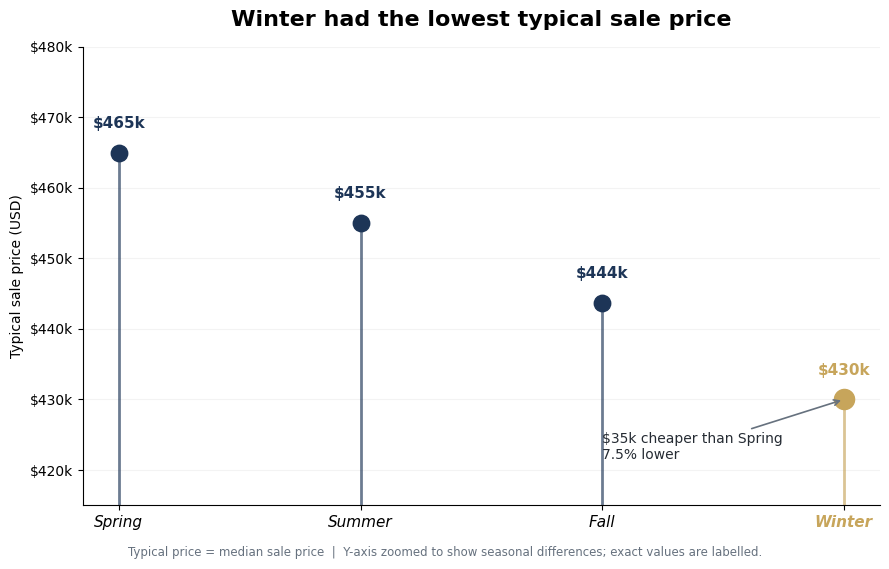

In [105]:
# Create the final H1 presentation chart.
# This compares the typical sale price across seasons.
#
# Important:
# - "Typical price" means median sale price.
# - The y-axis is intentionally zoomed because this is a point chart,
#   not a bar chart. Exact values are labelled to avoid misleading the audience.
# - Winter is highlighted because it had the lowest typical sale price.
# - Season names are italicised, with Winter additionally highlighted in gold.

import matplotlib.pyplot as plt

season_order = ["Spring", "Summer", "Fall", "Winter"]

season_plot = season_final.loc[season_order].copy()

# Presentation colours
navy = "#1D3557"
gold = "#C7A55B"
grey = "#66717E"

fig, ax = plt.subplots(figsize=(9, 5.5))

# Use a common visual baseline for the lollipop stems.
visual_baseline = 415000

# Draw stems.
for season in season_order:
    price = season_plot.loc[season, "median_price"]

    color = gold if season == "Winter" else navy

    ax.vlines(
        x=season,
        ymin=visual_baseline,
        ymax=price,
        color=color,
        linewidth=2,
        alpha=0.65
    )

# Draw points.
for season in season_order:
    price = season_plot.loc[season, "median_price"]

    color = gold if season == "Winter" else navy
    size = 210 if season == "Winter" else 140

    ax.scatter(
        season,
        price,
        s=size,
        color=color,
        zorder=3
    )

# Add exact price labels.
for season, row in season_plot.iterrows():
    color = gold if season == "Winter" else navy

    ax.text(
        season,
        row["median_price"] + 3500,
        f'${row["median_price"]/1000:.0f}k',
        ha="center",
        fontsize=11,
        fontweight="bold",
        color=color
    )

# Highlight the main Winter comparison.
ax.annotate(
    "$35k cheaper than Spring\n7.5% lower",
    xy=("Winter", winter_price),
    xytext=("Fall", 421500),
    arrowprops=dict(
        arrowstyle="->",
        color=grey,
        linewidth=1.2
    ),
    fontsize=10,
    color="#252B33"
)

# Client-friendly title and axis wording.
ax.set_title(
    "Winter had the lowest typical sale price",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Typical sale price (USD)")
ax.set_xlabel("")

# Zoom the y-axis to make the seasonal differences readable.
ax.set_ylim(415000, 480000)

# Format y-axis values as dollars in thousands.
ax.set_yticks([
    420000, 430000, 440000, 450000,
    460000, 470000, 480000
])

ax.set_yticklabels([
    "$420k", "$430k", "$440k", "$450k",
    "$460k", "$470k", "$480k"
])

# Italicise all season labels.
for label in ax.get_xticklabels():
    label.set_fontstyle("italic")
    label.set_fontsize(11)

# Highlight Winter on the x-axis.
for label in ax.get_xticklabels():
    if label.get_text() == "Winter":
        label.set_color(gold)
        label.set_fontweight("bold")

# Remove unnecessary borders.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep gridlines subtle.
ax.grid(axis="y", alpha=0.15)
ax.grid(axis="x", visible=False)

# Explain the statistic and the zoomed axis transparently.
fig.text(
    0.5,
    -0.02,
    "Typical price = median sale price  |  Y-axis zoomed to show seasonal differences; exact values are labelled.",
    ha="center",
    fontsize=8.5,
    color=grey
)

plt.tight_layout()
plt.show()

Y-axis zoomed to show seasonal differences. Exact values shown above each point.

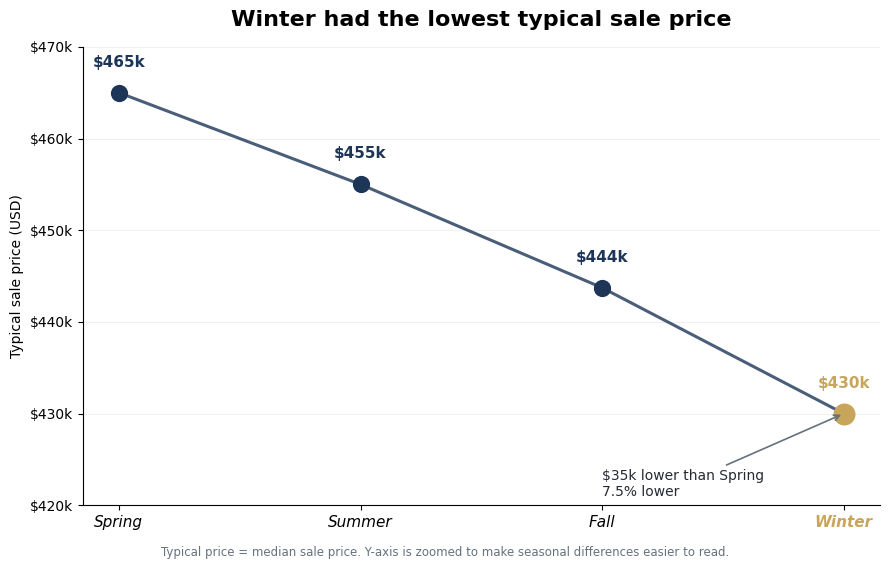

In [106]:
# Create a cleaner H1 chart using dots connected by a line.
# This chart shows the typical sale price across seasons.
#
# Why this version:
# - easier for non-technical people to read
# - cleaner than the lollipop chart
# - avoids the visual feel of "bars with a truncated axis"
# - Winter is highlighted because it has the lowest typical sale price
#
# Note:
# "Typical price" here means median sale price.

import matplotlib.pyplot as plt

season_order = ["Spring", "Summer", "Fall", "Winter"]
season_plot = season_final.loc[season_order].copy()

# Prepare x and y values
x = range(len(season_order))
y = season_plot["median_price"].values

# Colors
navy = "#1D3557"
gold = "#C7A55B"
grey = "#66717E"

fig, ax = plt.subplots(figsize=(9, 5.5))

# Draw connecting line
ax.plot(
    x, y,
    linewidth=2.2,
    color=navy,
    alpha=0.8
)

# Draw dots
for i, season in enumerate(season_order):
    price = season_plot.loc[season, "median_price"]
    color = gold if season == "Winter" else navy
    size = 220 if season == "Winter" else 130

    ax.scatter(
        i, price,
        s=size,
        color=color,
        zorder=3
    )

# Add value labels above dots
for i, season in enumerate(season_order):
    price = season_plot.loc[season, "median_price"]
    color = gold if season == "Winter" else navy

    ax.text(
        i,
        price + 2500,
        f"${price/1000:.0f}k",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=color
    )

# Add annotation for Winter vs Spring
spring_price = season_plot.loc["Spring", "median_price"]
winter_price = season_plot.loc["Winter", "median_price"]

winter_saving_usd = spring_price - winter_price
winter_saving_pct = (winter_saving_usd / spring_price) * 100

ax.annotate(
    f"${winter_saving_usd/1000:.0f}k lower than Spring\n{winter_saving_pct:.1f}% lower",
    xy=(3, winter_price),
    xytext=(2.0, 421000),
    arrowprops=dict(
        arrowstyle="->",
        color=grey,
        linewidth=1.2
    ),
    fontsize=10,
    color="#252B33"
)

# Title and labels
ax.set_title(
    "Winter had the lowest typical sale price",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Typical sale price (USD)")
ax.set_xlabel("")

# Set x-axis labels
ax.set_xticks(list(x))
ax.set_xticklabels(season_order)

# Italicize all season labels and highlight Winter
for label in ax.get_xticklabels():
    label.set_fontstyle("italic")
    label.set_fontsize(11)

    if label.get_text() == "Winter":
        label.set_color(gold)
        label.set_fontweight("bold")

# Keep y-axis zoomed for readability
ax.set_ylim(420000, 470000)

# Format y-axis ticks
ax.set_yticks([420000, 430000, 440000, 450000, 460000, 470000])
ax.set_yticklabels(["$420k", "$430k", "$440k", "$450k", "$460k", "$470k"])

# Clean up chart style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.18)
ax.grid(axis="x", visible=False)

# Add note for clarity
fig.text(
    0.5,
    -0.02,
    "Typical price = median sale price. Y-axis is zoomed to make seasonal differences easier to read.",
    ha="center",
    fontsize=8.5,
    color=grey
)

plt.tight_layout()
plt.show()

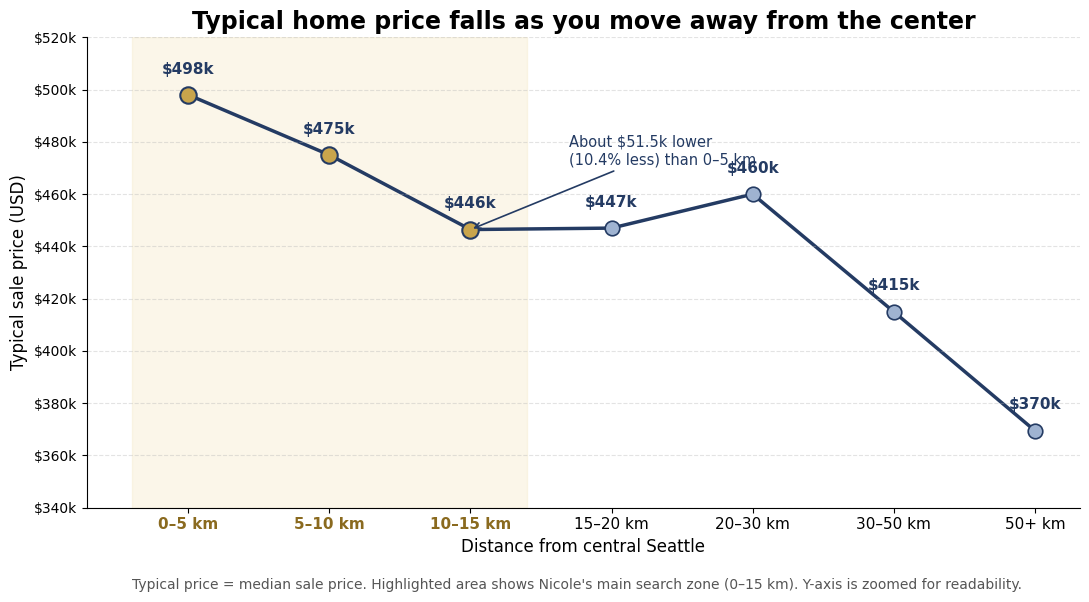

In [107]:
# Create a presentation-friendly H2 chart:
# "Typical home prices generally fall as distance from central Seattle increases."
# This chart:
# - uses all distance bands
# - highlights Nicole's main search zone (0–15 km)
# - shows the typical sale price in each band
# - annotates the key comparison: 10–15 km vs 0–5 km

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Prepare data for plotting
h2_plot = all_distance_summary.reset_index().copy()

# Keep the bands in the intended order
band_order = ["0–5 km", "5–10 km", "10–15 km", "15–20 km", "20–30 km", "30–50 km", "50+ km"]
h2_plot["distance_band"] = pd.Categorical(h2_plot["distance_band"], categories=band_order, ordered=True)
h2_plot = h2_plot.sort_values("distance_band").reset_index(drop=True)

# Create x and y values
x = list(range(len(h2_plot)))
y = h2_plot["median_price_usd"]

# Create figure
fig, ax = plt.subplots(figsize=(11, 6))

# Light highlight for Nicole's main search zone (0–15 km)
ax.axvspan(-0.4, 2.4, color="#F4E7C1", alpha=0.35)

# Main line across all distance bands
ax.plot(x, y, color="#243B63", linewidth=2.5, zorder=1)

# Highlight Nicole's priority bands
ax.scatter(x[:3], y[:3], s=140, color="#C9A54C", edgecolor="#243B63", linewidth=1.5, zorder=3)

# Show farther bands in a softer color
ax.scatter(x[3:], y[3:], s=110, color="#9FB3D1", edgecolor="#243B63", linewidth=1.2, zorder=3)

# Add value labels above each point
for i, value in enumerate(y):
    ax.text(
        x[i],
        value + 7000,
        f"${value/1000:.0f}k",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#243B63"
    )

# Annotate the key trade-off: 10–15 km vs 0–5 km
save_usd = h2_plot.loc[2, "price_saving_usd"]
save_pct = h2_plot.loc[2, "price_saving_pct"]

ax.annotate(
    f"About ${save_usd/1000:.1f}k lower\n({save_pct:.1f}% less) than 0–5 km",
    xy=(2, y.iloc[2]),
    xytext=(2.7, y.iloc[2] + 25000),
    arrowprops=dict(arrowstyle="->", color="#243B63", lw=1.2),
    fontsize=10.5,
    color="#243B63",
    ha="left"
)

# Titles and labels
ax.set_title("Typical home price falls as you move away from the center", fontsize=17, fontweight="bold")
ax.set_xlabel("Distance from central Seattle", fontsize=12)
ax.set_ylabel("Typical sale price (USD)", fontsize=12)

# X-axis labels
ax.set_xticks(x)
ax.set_xticklabels(h2_plot["distance_band"], fontsize=11)

# Make the first three tick labels stand out
for i, label in enumerate(ax.get_xticklabels()):
    if i < 3:
        label.set_fontweight("bold")
        label.set_color("#8A6A1F")

# Format y-axis as currency
ax.yaxis.set_major_formatter(FuncFormatter(lambda val, pos: f"${val/1000:.0f}k"))

# Zoom the y-axis for readability
ax.set_ylim(340000, 520000)

# Grid and styling
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add note below chart
fig.text(
    0.125,
    0.01,
    "Typical price = median sale price. Highlighted area shows Nicole's main search zone (0–15 km). Y-axis is zoomed for readability.",
    fontsize=10,
    color="#555555"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

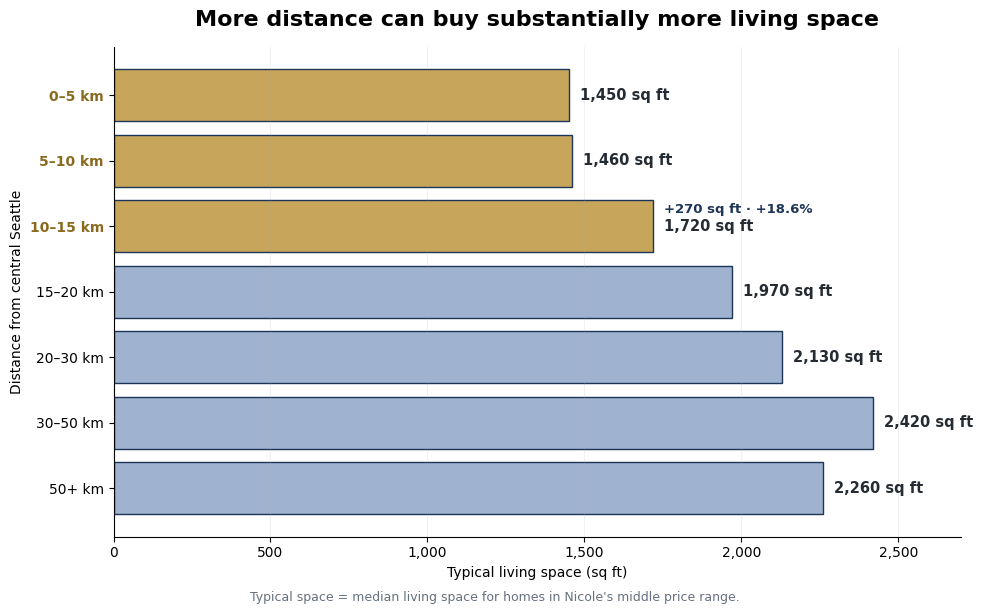

In [108]:
# Create the final H3 chart showing typical living space by distance band.
#
# This chart:
# - shows ALL distance bands for full market context
# - highlights the closer 0–15 km bands we are examining most closely for Nicole
# - uses a true zero baseline because bar length represents living space
# - directly labels the typical square footage
# - highlights the +270 sq ft / +18.6% difference between 0–5 km and 10–15 km
#
# "Typical space" means median living space within Nicole's middle price range.

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter

# Prepare the data in distance order.
h3_plot = all_distance_summary.reset_index().copy()

band_order = [
    "0–5 km",
    "5–10 km",
    "10–15 km",
    "15–20 km",
    "20–30 km",
    "30–50 km",
    "50+ km"
]

h3_plot["distance_band"] = pd.Categorical(
    h3_plot["distance_band"],
    categories=band_order,
    ordered=True
)

h3_plot = (
    h3_plot
    .sort_values("distance_band")
    .reset_index(drop=True)
)

# Presentation colors.
navy = "#1D3557"
gold = "#C7A55B"
steel = "#9FB3D1"
charcoal = "#252B33"

# Highlight the first three distance bands.
bar_colors = [
    gold,   # 0–5 km
    gold,   # 5–10 km
    gold,   # 10–15 km
    steel,  # 15–20 km
    steel,  # 20–30 km
    steel,  # 30–50 km
    steel   # 50+ km
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    h3_plot["distance_band"],
    h3_plot["median_space_sqft"],
    color=bar_colors,
    edgecolor=navy,
    linewidth=1
)

# Add direct square-foot labels.
for bar, value in zip(bars, h3_plot["median_space_sqft"]):
    ax.text(
        value + 35,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f} sq ft",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        color=charcoal
    )

# Highlight the 10–15 km gain compared with the 0–5 km baseline.
space_gain = h3_plot.loc[2, "extra_space_sqft"]
space_gain_pct = h3_plot.loc[2, "extra_space_pct"]

ax.text(
    h3_plot.loc[2, "median_space_sqft"] + 35,
    2 - 0.20,
    f"+{space_gain:,.0f} sq ft · +{space_gain_pct:.1f}%",
    fontsize=9.5,
    color=navy,
    fontweight="bold"
)

# Presentation-friendly title and axes.
ax.set_title(
    "More distance can buy substantially more living space",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Typical living space (sq ft)")
ax.set_ylabel("Distance from central Seattle")

# Bars should start at zero because their length represents magnitude.
ax.set_xlim(0, 2700)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, pos: f"{value:,.0f}")
)

# Put closest distance at the top.
ax.invert_yaxis()

# Style first three labels to match the highlighted bars.
for i, label in enumerate(ax.get_yticklabels()):
    if i < 3:
        label.set_fontweight("bold")
        label.set_color("#8A6A1F")

# Clean styling.
ax.grid(axis="x", alpha=0.18)
ax.grid(axis="y", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Methodology note.
fig.text(
    0.5,
    -0.01,
    "Typical space = median living space for homes in Nicole's middle price range.",
    ha="center",
    fontsize=9,
    color="#66717E"
)

plt.tight_layout()
plt.show()

In [109]:
# Build a summary trade-off chart for Nicole's key features.
# The chart compares all distance bands against the 0–5 km baseline.
#
# It shows:
# - price change (%) -> below 0 means cheaper
# - space change (%) -> above 0 means more living space
# - density change (%) -> below 0 means less dense / less urban
#
# This is useful for the final recommendation slide because it shows
# the main trade-off in one place.

summary_tradeoff = all_distance_summary.reset_index().copy()

# Rename the distance column clearly in case it comes from the index
summary_tradeoff = summary_tradeoff.rename(columns={"index": "distance_band"})

# Use the first row (0–5 km) as the baseline
baseline_price = summary_tradeoff.loc[0, "median_price_usd"]
baseline_space = summary_tradeoff.loc[0, "median_space_sqft"]
baseline_density = summary_tradeoff.loc[0, "population_density_people_per_km2"]

# Calculate percentage change vs the 0–5 km band
summary_tradeoff["price_change_pct"] = (
    (summary_tradeoff["median_price_usd"] - baseline_price)
    / baseline_price
    * 100
)

summary_tradeoff["space_change_pct"] = (
    (summary_tradeoff["median_space_sqft"] - baseline_space)
    / baseline_space
    * 100
)

summary_tradeoff["density_change_pct"] = (
    (summary_tradeoff["population_density_people_per_km2"] - baseline_density)
    / baseline_density
    * 100
)

summary_tradeoff

,distance_band,median_price_usd,median_space_sqft,population_density_people_per_km2,number_of_sales,price_saving_usd,price_saving_pct,extra_space_sqft,extra_space_pct,price_change_pct,space_change_pct,density_change_pct
0,0–5 km,498000.000,1450.000,3787.946,613,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,5–10 km,475000.000,1460.000,2938.082,2488,23000.000,4.618,10.000,0.690,-4.618,0.690,-22.436
2,10–15 km,446450.000,1720.000,2218.707,1811,51550.000,10.351,270.000,18.621,-10.351,18.621,-41.427
3,15–20 km,447000.000,1970.000,1492.051,2265,51000.000,10.241,520.000,35.862,-10.241,35.862,-60.611
4,20–30 km,460000.000,2130.000,906.269,2103,38000.000,7.631,680.000,46.897,-7.631,46.897,-76.075
5,30–50 km,415000.000,2420.000,199.558,1504,83000.000,16.667,970.000,66.897,-16.667,66.897,-94.732
6,50+ km,369500.000,2260.000,20.514,48,128500.000,25.803,810.000,55.862,-25.803,55.862,-99.458


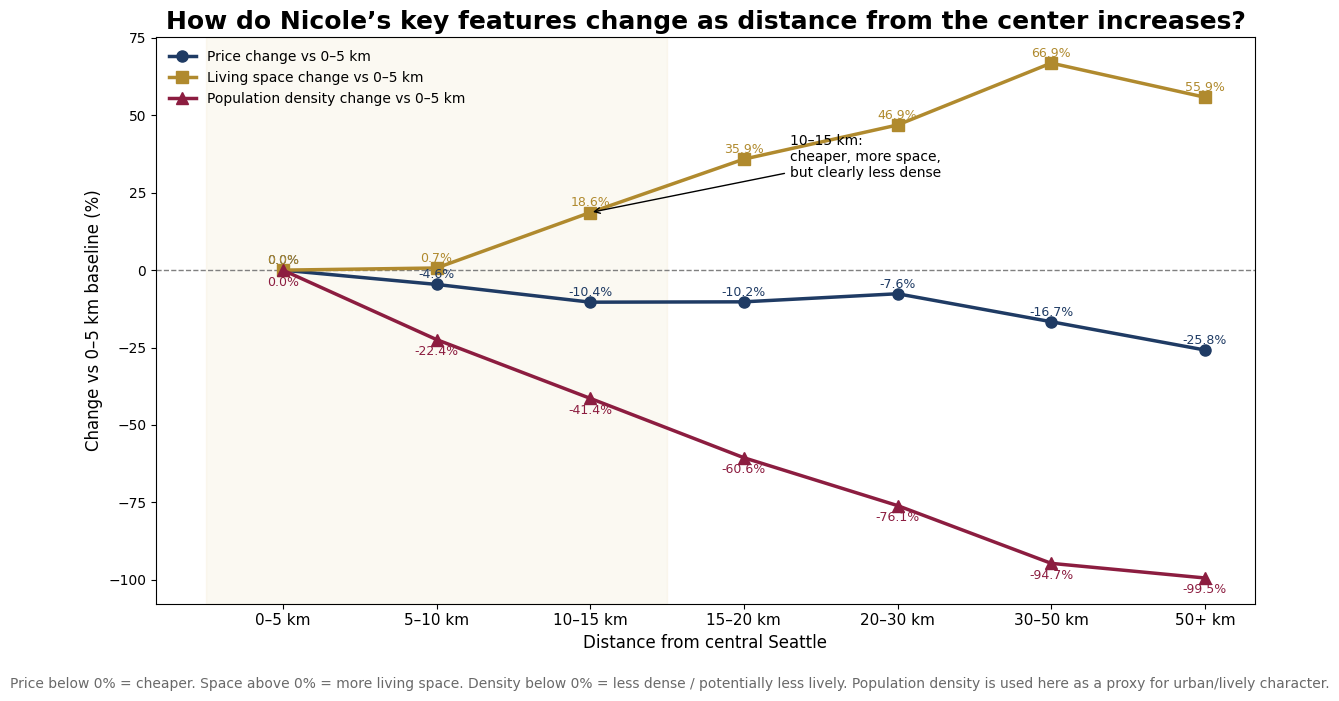

In [110]:
# Create a single summary chart that combines Nicole's key trade-offs.
# We highlight the 0–15 km area because that is still the more central search zone.

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(summary_tradeoff))
labels = summary_tradeoff["distance_band"]

price_color = "#1f3b64"    # navy
space_color = "#b08a2e"    # muted gold
density_color = "#8C1D40"  # slate blue-grey

plt.figure(figsize=(12, 7))

# Highlight Nicole's more central zone
plt.axvspan(-0.5, 2.5, color="#d8b365", alpha=0.08)

# Zero line
plt.axhline(0, color="gray", linestyle="--", linewidth=1)

# Plot the three trade-off lines
plt.plot(
    x,
    summary_tradeoff["price_change_pct"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color=price_color,
    label="Price change vs 0–5 km"
)

plt.plot(
    x,
    summary_tradeoff["space_change_pct"],
    marker="s",
    linewidth=2.5,
    markersize=8,
    color=space_color,
    label="Living space change vs 0–5 km"
)

plt.plot(
    x,
    summary_tradeoff["density_change_pct"],
    marker="^",
    linewidth=2.5,
    markersize=8,
    color=density_color,
    label="Population density change vs 0–5 km"
)

# Add value labels for each point
for i, value in enumerate(summary_tradeoff["price_change_pct"]):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center", fontsize=9, color=price_color)

for i, value in enumerate(summary_tradeoff["space_change_pct"]):
    plt.text(i, value + 2, f"{value:.1f}%", ha="center", fontsize=9, color=space_color)

for i, value in enumerate(summary_tradeoff["density_change_pct"]):
    plt.text(i, value - 5, f"{value:.1f}%", ha="center", fontsize=9, color=density_color)

# Optional: call out the 10–15 km band because it is an important trade-off point
plt.annotate(
    "10–15 km:\ncheaper, more space,\nbut clearly less dense",
    xy=(2, summary_tradeoff.loc[2, "space_change_pct"]),
    xytext=(3.3, 30),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10
)

plt.xticks(x, labels, fontsize=11)
plt.ylabel("Change vs 0–5 km baseline (%)", fontsize=12)
plt.xlabel("Distance from central Seattle", fontsize=12)

plt.title(
    "How do Nicole’s key features change as distance from the center increases?",
    fontsize=18,
    weight="bold"
)

plt.legend(frameon=False, loc="best")

plt.figtext(
    0.5,
    0.01,
    "Price below 0% = cheaper. Space above 0% = more living space. "
    "Density below 0% = less dense / potentially less lively. "
    "Population density is used here as a proxy for urban/lively character.",
    ha="center",
    fontsize=10,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

# 11. Final findings

### Finding 1 — Timing
Winter had the lowest median price in this one-year dataset, around **$35k below spring**.

### Finding 2 — Location
Homes closer to central Seattle were generally more expensive.

### Finding 3 — Space-price trade-off
For Nicole's middle-price segment, the **10–15 km** band offered a particularly useful balance:
- lower median price
- more living space
- still reasonably close to the centre

### Practical recommendation
Nicole should start by monitoring **98118, 98125, and 98126**, while remaining flexible around the 10–15 km area.

# 12. Limitations

These are important because EDA should not overstate what the data proves.

1. **Short time period**  
   The dataset covers roughly one year, so seasonal patterns may not repeat every year.

2. **Historical sales, not current listings**  
   A house sold in the dataset may not be available today.

3. **Distance is only one definition of centrality**  
   Real travel time depends on roads, traffic and public transport.

4. **Population density is only a proxy**  
   It does not directly measure neighbourhood quality, safety, walkability or lifestyle.

5. **Housing preferences are personal**  
   A "best" neighbourhood depends on factors not fully captured in the dataset.

# 13. Next steps

A stronger follow-up analysis could add:

- current listings
- commute/travel times
- public transport access
- schools
- crime/safety data
- walkability
- parks and amenities
- longer-term housing price data

This would turn the EDA from a historical market analysis into a more complete home-search decision tool.